### Working with Control pH 5 & 7, ArsS deletion pH 5 & 7

In [2]:
ctrl_ph7 = gffpd.read_gff3('../sample1_modification.gff') #Wild Type pH 7
arss_ph7 = gffpd.read_gff3('../sample2_modification.gff') #ArsS deletion pH 7, cannot detect pH change
ctrl_ph5 = gffpd.read_gff3('../sample5_modification.gff') #wild type pH 5
arss_ph5 = gffpd.read_gff3('../sample6_modification.gff') #ArsS deletion pH 5

#NOTE ANNOT, COUNTS, AND FREQ ARE ALL DATA FRAMES, NOT GFF DATA FRAMES
annot = pd.read_csv("../hpy_annot.tsv",sep='\t')#hpy annotation file
annot = annot.drop(columns=["seqname", "source", "feature", "score", "frame", "Prot_Size(est)", "attribute"]) #clean

tss = pd.read_csv("../TSS.csv")

In [3]:
ctrl_ph7 = ctrl_ph7.attributes_to_columns()
ctrl_ph5 = ctrl_ph5.attributes_to_columns()

arss_ph7 = arss_ph7.attributes_to_columns()
arss_ph5 = arss_ph5.attributes_to_columns()

In [4]:
ctrl_ph7 = ctrl_ph7[ctrl_ph7['IPDRatio'] >= '2']
ctrl_ph5 = ctrl_ph5[ctrl_ph5['IPDRatio'] >= '2']

arss_ph7 = arss_ph7[arss_ph7['IPDRatio'] >= '2']
arss_ph5 = arss_ph5[arss_ph5['IPDRatio'] >= '2']

In [7]:
# merging samples
frames = [ctrl_ph7, ctrl_ph5, arss_ph7, arss_ph5]
keys = ['ctrl pH7', 'ctrl pH5', 'arsS pH7', 'arsS pH5']
merged = pd.concat(frames, keys = keys)
merged = merged.reset_index(level=0).rename(columns={'level_0': 'sample'})
merged


,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC
6,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD
12,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82780,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663,GATC
82782,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447,DGAAGG
82783,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451,RCGDAD
82784,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644,GAAGA


In [46]:
ctrl_ph7[ctrl_ph7['motif'] == 'GCGTAC']

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
2854,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,56287,56287,417,-,.,context=TTTAGTTTGTTTTCTAGCGTACGAACAGGCACTAAAGA...,3.79,TTTAGTTTGTTTTCTAGCGTACGAACAGGCACTAAAGAGGC,430,GCGTAC,381,GCGTAC
5903,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,110235,110235,531,-,.,context=CCTAAATACGATGGAGGCGTACCGGAGAAAAAATTCGC...,4.23,CCTAAATACGATGGAGGCGTACCGGAGAAAAAATTCGCCTA,473,GCGTAC,497,GCGTAC
8950,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,169435,169435,512,+,.,context=TATAGGAACGCCAAAGGCGTACAGAAGGATTTGAAAAA...,4.02,TATAGGAACGCCAAAGGCGTACAGAAGGATTTGAAAAAAGC,463,GCGTAC,373,GCGTAC
14606,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,274627,274627,443,-,.,context=CGCTATAAGGTTTTCTGCGTACCGCTTCGGTCAATTGC...,3.89,CGCTATAAGGTTTTCTGCGTACCGCTTCGGTCAATTGCCCG,435,GCGTAC,405,GCGTAC
16738,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,317952,317952,511,+,.,context=CTAAAGAAGATTATGTGCGTACCGCTAAAGCTAAGGGG...,3.82,CTAAAGAAGATTATGTGCGTACCGCTAAAGCTAAGGGGTGT,539,GCGTAC,493,GCGTAC
22442,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,425032,425032,486,+,.,context=GTTCGACTCCCTTCGGGCGTACCACCTAACATTAATAC...,4.65,GTTCGACTCCCTTCGGGCGTACCACCTAACATTAATACCAT,399,GCGTAC,469,GCGTAC
23688,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,447913,447913,666,-,.,context=GTTCTGAACCCAGCTCGCGTACCGCTTTAAATGGCGAA...,4.97,GTTCTGAACCCAGCTCGCGTACCGCTTTAAATGGCGAACAG,592,GCGTAC,638,GCGTAC
33555,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,653453,653453,594,-,.,context=ATGTAGCCTAAATAAGGCGTACTAGAATGGAGCAATTG...,5.34,ATGTAGCCTAAATAAGGCGTACTAGAATGGAGCAATTGCCC,441,GCGTAC,580,GCGTAC
35579,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,693063,693063,483,+,.,context=ATCAAAAACCTTAAAAGCGTACCAGCTTTAGAAAAACT...,4.35,ATCAAAAACCTTAAAAGCGTACCAGCTTTAGAAAAACTGAA,425,GCGTAC,456,GCGTAC
36107,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,702147,702147,224,+,.,context=TGAGCGTAGAAGAGGGGCGTACTGGGCAGTTGCAATTT...,3.27,TGAGCGTAGAAGAGGGGCGTACTGGGCAGTTGCAATTTGGG,382,GCGTAC,274,GCGTAC


In [7]:
ctrl_ph7[ctrl_ph7['type'] == 'm4C']

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
28,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,531,531,618,+,.,context=GTTGTTTTTAATCTTTTTTTCTTCTAACATGCTAGAAG...,4.71,GTTGTTTTTAATCTTTTTTTCTTCTAACATGCTAGAAGCGA,548,GAAGA/TCTTC,605,TCTTC
32,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,564,564,274,+,.,context=AGAAGCGATTTTTTTAATTTCTTCATTACCGCTCTCAA...,2.60,AGAAGCGATTTTTTTAATTTCTTCATTACCGCTCTCAAACG,550,GAAGA/TCTTC,231,TCTTC
64,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1089,1089,278,+,.,coverage=563;context=TCCCTTGTAATTGCAATTTCCCTTC...,2.85,TCCCTTGTAATTGCAATTTCCCTTCTATGATTTGCATGAAA,563,None,168,None
123,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2192,2192,426,+,.,context=TTGCGGGTGGTTTTTTAACTCTTCTTTAACAGGCTCTA...,3.33,TTGCGGGTGGTTTTTTAACTCTTCTTTAACAGGCTCTAAAA,523,GAAGA/TCTTC,426,TCTTC
145,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2549,2549,144,+,.,context=CTCATAAAGCTCTTTAAGCTCTTCATATTCATTCTCTT...,2.18,CTCATAAAGCTCTTTAAGCTCTTCATATTCATTCTCTTGAA,525,GAAGA/TCTTC,119,TCTTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86410,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1666626,1666626,378,+,.,context=GCTCCCATAGTATTGCAACTCTTCAGCGATTCTTTCTG...,3.09,GCTCCCATAGTATTGCAACTCTTCAGCGATTCTTTCTGCGT,540,GAAGA/TCTTC,387,TCTTC
86443,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1667451,1667451,132,-,.,coverage=564;context=AAAAGTTTGGAAAAAATGAGCGATG...,2.01,AAAAGTTTGGAAAAAATGAGCGATGAGGAGATTAGAGAGCT,564,None,32,None
86448,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1667498,1667498,572,+,.,context=AATGCTAGAGAGCATGTTTTCTTCAATCAAAGTTGTGT...,4.09,AATGCTAGAGAGCATGTTTTCTTCAATCAAAGTTGTGTCAG,563,GAAGA/TCTTC,537,TCTTC
86459,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1667636,1667636,352,+,.,context=GCCCCCATAACGCTGCAATTCTTCAGCGATCCTTCTTG...,2.90,GCCCCCATAACGCTGCAATTCTTCAGCGATCCTTCTTGGGT,554,GAAGA/TCTTC,359,TCTTC


In [9]:
ctrl_ph5['motif'].value_counts()
#ctrl_ph5['motif'].value_counts()

#arss_ph7['motif'].value_counts()
#arss_ph5['motif'].value_counts()

motif
CATG                   14752
GATC                   10305
GANTC                   5236
TCTTC                   4767
RCGDAD                  4634
GAGG                    4526
GAAGA                   4308
GCAG                    4257
DGAAGG                  1135
ATTAAT                   952
YCGRATD                  469
HTCAVNNNNNNTGY           385
CTANNNNNNNNTGT           330
TCGA                     323
ACANNNNNNNNTAG           314
GAGG,GAAGA               240
RCGDAD,GATC              194
TCGA,GATC                186
GAAGA,GANTC              135
GAAGA,GATC               132
TCGA,GANTC                83
RCGDAD,GAGG               79
ACAGNNNNNNTGA             73
RCGDAD,GANTC              73
GCGCGVATNNNNNNNH          60
YCGAATC                   58
YCGRATD,GANTC             30
YCGAAGG                   21
GCGTAC                    19
TCGA,GAGG                 16
ACANNNNNNNNTAG,CATG       16
Name: count, dtype: int64

In [10]:
ctrl_ph7 = ctrl_ph5['motif'].value_counts()
ctrl_ph5.to_csv('ctrl5.csv')

In [11]:
ctrl_ph5

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,513,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.12,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,474,GAGG,484,GAGG
3,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,646,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,6.22,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,475,GANTC,596,GANTC
4,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,548,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.71,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,473,GANTC,535,GANTC
7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,626,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.39,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,480,RCGDAD,582,RCGDAD
13,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,623,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.59,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,470,RCGDAD,590,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85746,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,686,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.92,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,468,GATC,726,GATC
85748,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,506,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.72,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,454,DGAAGG,475,DGAAGG
85749,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,469,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.21,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,459,RCGDAD,460,RCGDAD
85753,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,638,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.27,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,469,GAAGA/TCTTC,665,GAAGA


In [40]:
ctrl_ph7[ctrl_ph7['start'] <= 17197]

,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
1,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG
2,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC
3,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC
6,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD
12,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
894,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17147,17147,485,+,.,context=ACGCAAAGCGCTTTTACAAGAGGGGCTGGTTATGTGGG...,4.42,ACGCAAAGCGCTTTTACAAGAGGGGCTGGTTATGTGGGCGC,444,GAGG,453,GAGG
896,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17172,17172,571,+,.,context=CTGGTTATGTGGGCGCTACCATGATTAATGATAATGTG...,5.23,CTGGTTATGTGGGCGCTACCATGATTAATGATAATGTGCGC,445,CATG,523,CATG
897,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17173,17173,473,-,.,context=CGCGCACATTATCATTAATCATGGTAGCGCCCACATAA...,4.44,CGCGCACATTATCATTAATCATGGTAGCGCCCACATAACCA,440,CATG,451,CATG
898,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,17176,17176,576,-,.,context=AAGCGCGCACATTATCATTAATCATGGTAGCGCCCACA...,5.33,AAGCGCGCACATTATCATTAATCATGGTAGCGCCCACATAA,433,ATTAAT,597,ATTAAT


In [8]:
counts = pd.DataFrame(columns=['gene', '1\' pH7','1\' pH5', '16\' pH7', '16\' pH5'])
counts['gene'] = annot['HP_number']
counts.head()

,gene,1' pH7,1' pH5,16' pH7,16' pH5
0,HP0001,NaN,NaN,NaN,NaN
1,HP0002,NaN,NaN,NaN,NaN
2,HP0003,NaN,NaN,NaN,NaN
3,HP0004,NaN,NaN,NaN,NaN
4,HP0005,NaN,NaN,NaN,NaN


In [9]:
for ind in counts.index: 
    counts.loc[ind, '1\' pH7']=((ctrl_ph7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    counts.loc[ind, '1\' pH5']=((ctrl_ph5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    counts.loc[ind, '16\' pH7']=((arss_ph7['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()
    counts.loc[ind, '16\' pH5']=((arss_ph5['start'].between(annot.loc[ind,'start'], annot.loc[ind,'end']+1))).sum()

In [10]:
counts

,gene,1' pH7,1' pH5,16' pH7,16' pH5
0,HP0001,16,16,16,16
1,HP0002,25,26,24,24
2,HP0003,31,31,31,31
3,HP0004,27,27,25,24
4,HP0005,22,23,24,23
...,...,...,...,...,...
1585,HP1586,8,8,8,8
1586,HP1587,24,24,24,24
1587,HP1588,32,32,32,32
1588,HP1589,29,29,28,28


In [11]:
for ind in counts.index:
    gene_length = annot.loc[ind,'end'] - annot.loc[ind,'start']
    counts.loc[ind, '1\' pH7 density'] = counts.loc[ind, '1\' pH7'] / gene_length
    counts.loc[ind, '16\' pH7 density'] = counts.loc[ind, '16\' pH7'] / gene_length
    counts.loc[ind, '1\' pH5 density'] = counts.loc[ind, '1\' pH5'] / gene_length
    counts.loc[ind, '16\' pH5 density'] = counts.loc[ind, '16\' pH5'] / gene_length

In [12]:
counts

,gene,1' pH7,1' pH5,16' pH7,16' pH5,1' pH7 density,16' pH7 density,1' pH5 density,16' pH5 density
0,HP0001,16,16,16,16,0.038741,0.038741,0.038741,0.038741
1,HP0002,25,26,24,24,0.053533,0.051392,0.055675,0.051392
2,HP0003,31,31,31,31,0.037485,0.037485,0.037485,0.037485
3,HP0004,27,27,25,24,0.040785,0.037764,0.040785,0.036254
4,HP0005,22,23,24,23,0.032353,0.035294,0.033824,0.033824
...,...,...,...,...,...,...,...,...,...
1585,HP1586,8,8,8,8,0.023881,0.023881,0.023881,0.023881
1586,HP1587,24,24,24,24,0.051724,0.051724,0.051724,0.051724
1587,HP1588,32,32,32,32,0.042216,0.042216,0.042216,0.042216
1588,HP1589,29,29,28,28,0.046774,0.045161,0.046774,0.045161


In [19]:
counts.to_csv('gene_counts.csv')

## PCA Plots

In [43]:
from sklearn.decomposition import PCA

In [44]:
columns_to_drop = ['1\' pH7', '1\' pH5', '16\' pH7', '16\' pH5']
freq = counts.drop(columns=columns_to_drop)

In [45]:
freq = freq.set_index('gene')

In [46]:
freq_pca = freq.transpose()
freq_pca = freq_pca.drop("Unnamed: 0")
freq_pca

gene,HP0001,HP0002,HP0003,HP0004,HP0005,HP0006,HP0007,HP0008,HP0009,HP0010,...,HP1581,HP1582,HP1583,HP1584,HP1585,HP1586,HP1587,HP1588,HP1589,HP1590
1' pH7 density,0.038741,0.053533,0.037485,0.040785,0.032353,0.021765,0.029412,0.05,0.036823,0.053757,...,0.025819,0.034395,0.034783,0.030422,0.038217,0.023881,0.051724,0.042216,0.046774,0.025862
16' pH7 density,0.038741,0.051392,0.037485,0.037764,0.035294,0.021765,0.029412,0.05,0.035771,0.051313,...,0.025819,0.034395,0.034783,0.029441,0.038217,0.023881,0.051724,0.042216,0.045161,0.017241
1' pH5 density,0.038741,0.055675,0.037485,0.040785,0.033824,0.021765,0.029412,0.05,0.035771,0.051924,...,0.025819,0.034395,0.033696,0.030422,0.038217,0.023881,0.051724,0.042216,0.046774,0.017241
16' pH5 density,0.038741,0.051392,0.037485,0.036254,0.033824,0.021765,0.029412,0.05,0.035771,0.051924,...,0.025819,0.034395,0.034783,0.029441,0.038217,0.023881,0.051724,0.042216,0.045161,0.017241


In [47]:
freq_pca['sample'] = ['ctrl_7', 'ctrl_5', 'arsS_7', 'arsS_5']
freq_pca

gene,HP0001,HP0002,HP0003,HP0004,HP0005,HP0006,HP0007,HP0008,HP0009,HP0010,...,HP1582,HP1583,HP1584,HP1585,HP1586,HP1587,HP1588,HP1589,HP1590,sample
1' pH7 density,0.038741,0.053533,0.037485,0.040785,0.032353,0.021765,0.029412,0.05,0.036823,0.053757,...,0.034395,0.034783,0.030422,0.038217,0.023881,0.051724,0.042216,0.046774,0.025862,ctrl_7
16' pH7 density,0.038741,0.051392,0.037485,0.037764,0.035294,0.021765,0.029412,0.05,0.035771,0.051313,...,0.034395,0.034783,0.029441,0.038217,0.023881,0.051724,0.042216,0.045161,0.017241,ctrl_5
1' pH5 density,0.038741,0.055675,0.037485,0.040785,0.033824,0.021765,0.029412,0.05,0.035771,0.051924,...,0.034395,0.033696,0.030422,0.038217,0.023881,0.051724,0.042216,0.046774,0.017241,arsS_7
16' pH5 density,0.038741,0.051392,0.037485,0.036254,0.033824,0.021765,0.029412,0.05,0.035771,0.051924,...,0.034395,0.034783,0.029441,0.038217,0.023881,0.051724,0.042216,0.045161,0.017241,arsS_5


In [48]:
pca = PCA(n_components = 2)
pca_X = pca.fit_transform(freq_pca.drop(columns = 'sample'))

/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_20565/2259015450.py:3: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  pca_freq = sns.scatterplot(x = pca_X[:,0], y = pca_X[:,1], hue = freq_pca['sample'],#style = freq_pca['sample'],


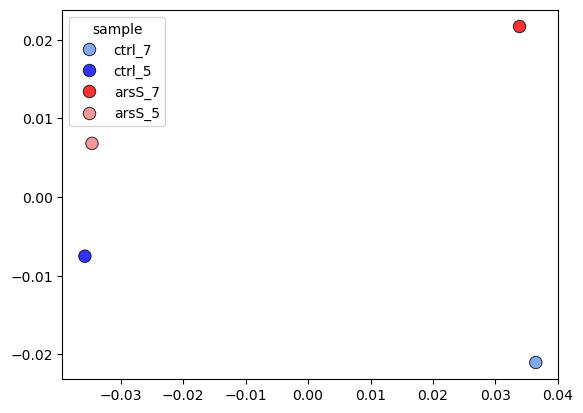

In [49]:
import seaborn as sns

pca_freq = sns.scatterplot(x = pca_X[:,0], y = pca_X[:,1], hue = freq_pca['sample'],#style = freq_pca['sample'],
                markers = ['o','s'], palette= ['cornflowerblue','b', 'r', 'lightcoral', 'g', 'y'],s = 80,
                           alpha = 0.8, ec = 'k')

/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_20565/960937139.py:5: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  pca_freq = sns.scatterplot(x=pca_X[:, 0], y=pca_X[:, 1], hue=freq_pca['sample'],


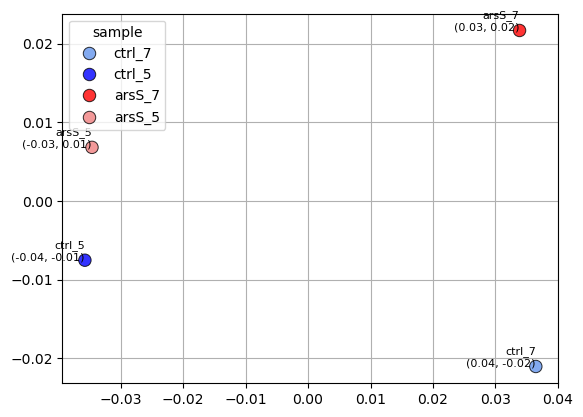

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Your existing PCA scatter plot code
pca_freq = sns.scatterplot(x=pca_X[:, 0], y=pca_X[:, 1], hue=freq_pca['sample'],
                            markers=['o', 's'], palette=['cornflowerblue', 'b', 'r', 'lightcoral', 'g', 'y'],
                            s=80, alpha=0.8, ec='k')

# Add grid to the plot
pca_freq.grid(True)

# Annotate each point with sample name
for i, txt in enumerate(freq_pca['sample']):
    plt.annotate(f'{txt}\n({pca_X[i, 0]:.2f}, {pca_X[i, 1]:.2f})', (pca_X[i, 0], pca_X[i, 1]), fontsize=8, ha='right')

# Show the plot
plt.show()

In [51]:
pca.components_

array([[-1.28360395e-18,  4.50704597e-02,  7.38922956e-19, ...,
         0.00000000e+00,  2.29148247e-02,  6.35041198e-02],
       [ 6.32570724e-16,  4.71454287e-02,  3.09105747e-18, ...,
         0.00000000e+00,  1.07078053e-03, -1.78354718e-01]])

In [52]:
pca_genes = pd.DataFrame(pca.components_, index = ['PC1', 'PC2'], columns = freq_pca.drop(columns = ['sample']).columns)
pca_genes

gene,HP0001,HP0002,HP0003,HP0004,HP0005,HP0006,HP0007,HP0008,HP0009,HP0010,...,HP1581,HP1582,HP1583,HP1584,HP1585,HP1586,HP1587,HP1588,HP1589,HP1590
PC1,-1.283604e-18,0.045070,7.389230e-19,0.053479,-0.021448,0.0,0.0,0.0,0.007750,0.017909,...,0.0,0.0,-0.007436,0.013942,0.0,0.0,0.0,0.0,0.022915,0.063504
PC2,6.325707e-16,0.047145,3.091057e-18,-0.008157,0.019555,0.0,0.0,0.0,-0.021767,-0.033400,...,0.0,0.0,-0.023210,0.000652,0.0,0.0,0.0,0.0,0.001071,-0.178355


In [53]:
pc = pca_genes.transpose()

pc.loc[(pc['PC1'] >= 0.1) | (pc['PC1'] <= -0.1) | (pc['PC2'] >= 0.1) | (pc['PC2'] <= -0.1)]

,PC1,PC2
gene,,
HP0065,0.058635,0.183026
HP0164,0.672088,0.031406
HP0165,0.219416,0.010253
HP0177,0.126850,0.005928
HP0332,0.155569,-0.084180
HP0385,-0.000653,0.123704
HP0445,0.115648,0.120972
HP0491,-0.000801,0.151788
HP0551,0.107868,-0.100126


### Promoter Interest

In [13]:
tss = pd.read_csv("../TSS.csv")

In [26]:
tss

,TSS,Strand,Locus_tag,Name,Primary,Secondary,Internal,Antisense,Enriched,Location,Putative sRNA,Putative asRNA,Sequence -50 nt upstream + TSS (51nt),Comment
0,1295653,+,6S_RNA,6S_RNA,0,0,0,1,1,0,0,0,TCCTTAGCGATGAGTTCAAAAATCTCTTCTCTAGCGATAGGATCAA...,-
1,2081,-,HP0003,2-dehydro-3-deoxyphosphooctonate aldolase,1,0,0,0,1,0,0,0,GTTTGAATGCGCGCTTGCAACTCAACAACCTCTTAAGCTATGATTT...,-
2,2672,+,HP0004,carbonic anhydrase (icfA),0,0,0,1,0,1,0,0,GATTAAAATTCGTTTGTTTTTAAAACGCTTATCATAGCTAAAATTC...,-
3,2646,-,HP0004,carbonic anhydrase (icfA),1,0,0,0,1,0,0,0,TAACGCCATTATAACAAAAAGAAATGCAAGAATTTTAGCTATGATA...,-
4,2646,-,HP0005,orotidine 5'-phosphate decarboxylase,0,0,0,1,1,0,0,0,TAACGCCATTATAACAAAAAGAAATGCAAGAATTTTAGCTATGATA...,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896,1233920,+,sRNA_Li_50,sRNA_Li_50,1,0,0,0,1,0,1,0,ACTTGAGCGGTAGCGTGGATCTTGCATATTATGGCGTGTATACTAA...,-
1897,1245780,-,sRNA_Li_7,sRNA_Li_7,0,0,0,1,1,0,1,0,AAACAACAACTTTACACCCCAAAAATGAAATTTTGAGGTATAATGT...,-
1898,1209438,+,sRNA_Li_9,sRNA_Li_9,0,0,0,1,1,0,1,1,ACCCTCACTCTATTTAGTCAGTCATTACTTATTTTATTTTAGAATA...,-
1899,16824,+,SRP_RNA,SRP_RNA,0,0,0,1,1,0,0,0,TTTTAGCCATAAAAAGCTTATGTTTTCATTAAAAATGTTATGATAC...,-


In [25]:
primary = tss[(tss['Primary'] == 1)]
primary

,TSS,Strand,Locus_tag,Name,Primary,Secondary,Internal,Antisense,Enriched,Location,Putative sRNA,Putative asRNA,Sequence -50 nt upstream + TSS (51nt),Comment
1,2081,-,HP0003,2-dehydro-3-deoxyphosphooctonate aldolase,1,0,0,0,1,0,0,0,GTTTGAATGCGCGCTTGCAACTCAACAACCTCTTAAGCTATGATTT...,-
3,2646,-,HP0004,carbonic anhydrase (icfA),1,0,0,0,1,0,0,0,TAACGCCATTATAACAAAAAGAAATGCAAGAATTTTAGCTATGATA...,-
6,2672,+,HP0005,orotidine 5'-phosphate decarboxylase,1,0,0,0,0,1,0,0,GATTAAAATTCGTTTGTTTTTAAAACGCTTATCATAGCTAAAATTC...,-
8,7321,-,HP0009,outer membrane protein,1,0,0,0,1,0,0,0,TTCTCCAAATGACAAAAAAAAAAAAAACGATTTTATGCTACAATGC...,-
9,9683,-,HP0011,co-chaperonin GroES,1,0,0,0,1,0,0,0,CTTTGTTTTTATGGCTTGACTTATCCCTAAAAATGCGCTATAGTTA...,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873,1245780,-,sRNA_Li_15,sRNA_Li_15,1,0,0,0,1,0,1,0,AAACAACAACTTTACACCCCAAAAATGAAATTTTGAGGTATAATGT...,-
1878,497713,-,sRNA_Li_22,sRNA_Li_22,1,0,0,0,1,0,1,0,ATCAAGCGCTCGTTATGCCCTTGTTAGAAAAGTTTAAGCTAGAATT...,-
1891,1170409,-,sRNA_Li_42,sRNA_Li_42,1,0,0,0,1,0,0,1,TTTTTTCAAACAATTCTTCTTTGTTAAGGTAGCTAGTGATAATATA...,-
1896,1233920,+,sRNA_Li_50,sRNA_Li_50,1,0,0,0,1,0,1,0,ACTTGAGCGGTAGCGTGGATCTTGCATATTATGGCGTGTATACTAA...,-


In [22]:
def calculate_adjusted_tss(row):
    if row['Strand'] == '+':
        return row['TSS'] - 50  # Subtract 50 bp for the + strand
    elif row['Strand'] == '-':
        return row['TSS'] + 50  # Add 50 bp for the - strand
    else:
        return row['TSS']

primary['+/- 50 TSS'] = primary.apply(calculate_adjusted_tss, axis=1)

new_df = primary[['TSS', '+/- 50 TSS',  'Strand', 'Locus_tag']]

/var/folders/kw/19vs2__d3bl_tx91fly_4sg40000gn/T/ipykernel_13944/3106624179.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  primary['+/- 50 TSS'] = primary.apply(calculate_adjusted_tss, axis=1)


In [23]:
new_df

,TSS,+/- 50 TSS,Strand,Locus_tag
1,2081,2131,-,HP0003
3,2646,2696,-,HP0004
6,2672,2622,+,HP0005
8,7321,7371,-,HP0009
9,9683,9733,-,HP0011
...,...,...,...,...
1873,1245780,1245830,-,sRNA_Li_15
1878,497713,497763,-,sRNA_Li_22
1891,1170409,1170459,-,sRNA_Li_42
1896,1233920,1233870,+,sRNA_Li_50


In [21]:
p_counts = pd.DataFrame(columns=['gene', '-Val', 'strand', '1\' pH7',\
                                 '1\' pH5', '16\' pH5','16\' pH7'])
p_counts['gene'] = new_df['Locus_tag']
p_counts['strand']= new_df['Strand']
p_counts['TSS'] = new_df['TSS']
p_counts['-Val'] = new_df['+/- 50 TSS']
p_counts

,gene,-Val,strand,1' pH7,1' pH5,16' pH5,16' pH7,TSS
1,HP0003,2131,-,NaN,NaN,NaN,NaN,2081
3,HP0004,2696,-,NaN,NaN,NaN,NaN,2646
6,HP0005,2622,+,NaN,NaN,NaN,NaN,2672
8,HP0009,7371,-,NaN,NaN,NaN,NaN,7321
9,HP0011,9733,-,NaN,NaN,NaN,NaN,9683
...,...,...,...,...,...,...,...,...
1873,sRNA_Li_15,1245830,-,NaN,NaN,NaN,NaN,1245780
1878,sRNA_Li_22,497763,-,NaN,NaN,NaN,NaN,497713
1891,sRNA_Li_42,1170459,-,NaN,NaN,NaN,NaN,1170409
1896,sRNA_Li_50,1233870,+,NaN,NaN,NaN,NaN,1233920


In [31]:
for ind in p_counts.index: 
    tss_value = int(tss_df.loc[ind, 'TSS'])
    val_value = int(tss_df.loc[ind, '-Val'])
    strand = tss_df.loc[ind, 'Strand']
    # Determine the range based on strand
    if strand == '-':
        range_start = tss_value
        range_end = val_value
    elif strand == '+':
        range_start = val_value
        range_end = tss_value
    # Update p_counts with the counts from the ranges
    p_counts.loc[ind, "1' pH7"] = (ctrl_ph7['start'].between(range_start, range_end)).sum()
    p_counts.loc[ind, "1' pH5"] = (ctrl_ph5['start'].between(range_start, range_end)).sum()
    p_counts.loc[ind, "16' pH7"] = (arss_ph7['start'].between(range_start, range_end)).sum()
    p_counts.loc[ind, "16' pH5"] = (arss_ph5['start'].between(range_start, range_end)).sum()

In [32]:
p_counts

,gene,-Val,strand,1' pH7,1' pH5,16' pH5,16' pH7,TSS
1,HP0003,2131,-,3,3,1,2,2081
3,HP0004,2696,-,0,0,0,0,2646
6,HP0005,2622,+,1,1,1,1,2672
8,HP0009,7371,-,0,0,0,0,7321
9,HP0011,9733,-,0,0,0,0,9683
...,...,...,...,...,...,...,...,...
1873,sRNA_Li_15,1245830,-,3,3,3,3,1245780
1878,sRNA_Li_22,497763,-,0,0,0,0,497713
1891,sRNA_Li_42,1170459,-,2,2,2,2,1170409
1896,sRNA_Li_50,1233870,+,2,2,2,2,1233920


In [38]:
tss_df

,TSS,+/- 50 TSS,Strand,Locus_tag,-Val
1,2081,2131,-,HP0003,2131
3,2646,2696,-,HP0004,2696
6,2672,2622,+,HP0005,2622
8,7321,7371,-,HP0009,7371
9,9683,9733,-,HP0011,9733
...,...,...,...,...,...
1873,1245780,1245830,-,sRNA_Li_15,1245830
1878,497713,497763,-,sRNA_Li_22,497763
1891,1170409,1170459,-,sRNA_Li_42,1170459
1896,1233920,1233870,+,sRNA_Li_50,1233870


In [63]:
merged[(merged['start'] >= 1484458) & (merged['end'] <= 1484508)]

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif
76604,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484475,1484475,721,+,.,context=TTTTAGCGCCTAAGGATTTGAGGTTTAGTTCAGGGGTC...,5.57,TTTTAGCGCCTAAGGATTTGAGGTTTAGTTCAGGGGTCATT,596,GAGG,695,GAGG
76607,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484494,1484494,521,-,.,context=CTTAAATCAAGGAAAGATTAATGACCCCTGAACTAAAC...,3.94,CTTAAATCAAGGAAAGATTAATGACCCCTGAACTAAACCTC,599,ATTAAT,532,ATTAAT
76608,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484497,1484497,847,+,.,context=GTTTAGTTCAGGGGTCATTAATCTTTCCTTGATTTAAG...,6.73,GTTTAGTTCAGGGGTCATTAATCTTTCCTTGATTTAAGTTA,596,ATTAAT,816,ATTAAT
76012,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1484468,1484468,147,-,.,coverage=483;context=CCTGAACTAAACCTCAAATCCTTAG...,2.05,CCTGAACTAAACCTCAAATCCTTAGGCGCTAAAACGCCCTA,483,None,107,None
76013,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484475,1484475,553,+,.,context=TTTTAGCGCCTAAGGATTTGAGGTTTAGTTCAGGGGTC...,5.18,TTTTAGCGCCTAAGGATTTGAGGTTTAGTTCAGGGGTCATT,513,GAGG,527,GAGG
76016,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484494,1484494,487,-,.,context=CTTAAATCAAGGAAAGATTAATGACCCCTGAACTAAAC...,3.98,CTTAAATCAAGGAAAGATTAATGACCCCTGAACTAAACCTC,513,ATTAAT,492,ATTAAT
76017,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484497,1484497,731,+,.,context=GTTTAGTTCAGGGGTCATTAATCTTTCCTTGATTTAAG...,6.60,GTTTAGTTCAGGGGTCATTAATCTTTCCTTGATTTAAGTTA,522,ATTAAT,701,ATTAAT
76233,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1484468,1484468,157,-,.,coverage=568;context=CCTGAACTAAACCTCAAATCCTTAG...,2.04,CCTGAACTAAACCTCAAATCCTTAGGCGCTAAAACGCCCTA,568,None,119,None
76234,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484475,1484475,743,+,.,context=TTTTAGCGCCTAAGGATTTGAGGTTTAGTTCAGGGGTC...,5.87,TTTTAGCGCCTAAGGATTTGAGGTTTAGTTCAGGGGTCATT,604,GAGG,712,GAGG
76237,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1484494,1484494,578,-,.,context=CTTAAATCAAGGAAAGATTAATGACCCCTGAACTAAAC...,4.05,CTTAAATCAAGGAAAGATTAATGACCCCTGAACTAAACCTC,606,ATTAAT,569,ATTAAT


In [52]:
p_counts.to_csv('promoter_methyl_counts.csv', index = False)

In [17]:
test = p_counts['-Val'].to_numpy()
sorted = np.sort(test)
print(sorted[104], sorted[106])

109077 111138


In [18]:
#do preparatory stuff
val_arr = p_counts['-Val'].to_numpy()
val_arr = np.sort(val_arr)
end = len(val_arr)-1
final = val_arr[end]+100
arr2 = []

#make array of 1s and 0s
cur_counter = 0
for i in range(final):
    cur_val = val_arr[cur_counter]
    if i < cur_val:
        arr2.append(0)
    elif cur_val <= i < cur_val+100:
        arr2.append(1)
    elif i == cur_val + 100:
        arr2.append(1)
        cur_counter += 1
        if val_arr[cur_counter] == cur_val:
            while val_arr[cur_counter] == cur_val:
                cur_counter += 1
    else:
        print(i, cur_val, cur_counter)
        pass
arr2.append(1)
print(arr2[final])
print(len(arr2))

1
1667018


In [19]:
ctrl_7_p = ctrl_ph7.drop(columns = ['seq_id', 'source', 'phase', 'attributes', 'identificationQv'])
ctrl_7_p['Classification'] = np.nan
ctrl_7_p

,type,start,end,score,strand,IPDRatio,context,coverage,id,motif,Classification
1,m6A,217,217,579,-,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,GAGG,NaN
2,m6A,255,255,713,+,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,GANTC,NaN
3,m6A,257,257,604,-,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,GANTC,NaN
6,m6A,300,300,740,+,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,RCGDAD,NaN
12,m6A,368,368,769,-,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,RCGDAD,NaN
...,...,...,...,...,...,...,...,...,...,...,...
86463,m6A,1667648,1667648,575,-,4.99,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,541,DGAAGG,DGAAGG,NaN
86464,m6A,1667666,1667666,555,+,4.30,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,555,RCGDAD,RCGDAD,NaN
86465,m6A,1667716,1667716,125,+,2.04,AACTTGTCAATTATTCATTCATTCTTAGTGTGCCATCTTCA,561,None,None,NaN
86468,m6A,1667731,1667731,736,-,5.43,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,553,GAAGA/TCTTC,GAAGA,NaN


In [20]:
# Function to apply to each row of the DataFrame
genome_array = arr2
methylation_df = merged

def classify_promoter(row):
    start_location = row['start']
    if start_location < len(genome_array):  # Check if start location is within range
        if genome_array[start_location] == 1:
            return 'Promoter'
        else:
            return np.nan
    else:
        return np.nan  # Return NaN if start location is out of range

# Apply the function to the DataFrame
methylation_df['Classification'] = methylation_df.apply(classify_promoter, axis=1)

methylation_df

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG,NaN
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC,NaN
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC,NaN
6,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD,NaN
12,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82780,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663,GATC,NaN
82782,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447,DGAAGG,NaN
82783,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451,RCGDAD,NaN
82784,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644,GAAGA,NaN


In [21]:
prom = methylation_df[methylation_df['Classification'] == 'Promoter']

In [22]:
prom

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification
119,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,2136,2136,109,-,.,coverage=550;context=GCCAAGCGTTCATGGCTTACAGAGC...,2.01,GCCAAGCGTTCATGGCTTACAGAGCGTTTGAATGCGCGCTT,550,None,None,None,Promoter
120,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2144,2144,602,+,.,context=ATTCAAACGCTCTGTAAGCCATGAACGCTTGGCGAAAT...,4.74,ATTCAAACGCTCTGTAAGCCATGAACGCTTGGCGAAATGGT,547,CATG,583,CATG,Promoter
121,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2145,2145,636,-,.,context=AACCATTTCGCCAAGCGTTCATGGCTTACAGAGCGTTT...,4.69,AACCATTTCGCCAAGCGTTCATGGCTTACAGAGCGTTTGAA,555,CATG,605,CATG,Promoter
122,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2191,2191,683,-,.,context=TTTAGAGCCTGTTAAAGAAGAGTTAAAAAACCACCCGC...,5.57,TTTAGAGCCTGTTAAAGAAGAGTTAAAAAACCACCCGCAAT,548,GAAGA/TCTTC,672,GAAGA,Promoter
123,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,2192,2192,426,+,.,context=TTGCGGGTGGTTTTTTAACTCTTCTTTAACAGGCTCTA...,3.33,TTGCGGGTGGTTTTTTAACTCTTCTTTAACAGGCTCTAAAA,523,GAAGA/TCTTC,426,TCTTC,Promoter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82699,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665570,1665570,547,+,.,context=TAGCATCATTTTTTAAAATCATGTCTAACGCCCTAAAA...,4.53,TAGCATCATTTTTTAAAATCATGTCTAACGCCCTAAAAGGC,455,CATG,512,CATG,Promoter
82700,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665571,1665571,633,-,.,context=AGCCTTTTAGGGCGTTAGACATGATTTTAAAAAATGAT...,5.91,AGCCTTTTAGGGCGTTAGACATGATTTTAAAAAATGATGCT,454,CATG,600,CATG,Promoter
82702,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665609,1665609,501,-,.,context=GTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGTTTA...,4.72,GTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGTTTAAGC,455,GCAG,479,GCAG,Promoter
82703,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665614,1665614,420,+,.,context=AACACACCCGCTAACTGCACATGAATATTGCACTACAA...,3.90,AACACACCCGCTAACTGCACATGAATATTGCACTACAAATG,455,CATG,387,CATG,Promoter


In [23]:
cr = methylation_df[methylation_df['Classification'] != 'Promoter']

In [24]:
methylation_df

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG,NaN
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC,NaN
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC,NaN
6,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD,NaN
12,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82780,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663,GATC,NaN
82782,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447,DGAAGG,NaN
82783,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451,RCGDAD,NaN
82784,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644,GAAGA,NaN


In [68]:
p_counts

NameError: name 'p_counts' is not defined

## PCA plots with PROM region

In [33]:
freq_tss = p_counts.copy()
freq_tss['1\' pH7'] = freq_tss['1\' pH7'].div(50)
freq_tss['1\' pH5'] = freq_tss['1\' pH5'].div(50)
freq_tss['16\' pH7'] = freq_tss['16\' pH7'].div(50)
freq_tss['16\' pH5'] = freq_tss['16\' pH5'].div(50)
freq_tss

,gene,-Val,strand,1' pH7,1' pH5,16' pH5,16' pH7,TSS
7,HP0003,2031,-,0.0,0.0,0.0,0.0,2081
8,HP0004,2031,-,0.0,0.0,0.0,0.0,2081
9,HP0004,2596,-,0.02,0.02,0.02,0.02,2646
10,HP0005,2596,-,0.02,0.02,0.02,0.02,2646
11,HP0005,2622,+,0.02,0.02,0.02,0.02,2672
...,...,...,...,...,...,...,...,...
2499,HP1581,1660530,+,0.02,0.02,0.02,0.02,1660580
2500,HP1582,1660530,+,0.02,0.02,0.02,0.02,1660580
2501,HP1585,1663510,+,0.02,0.02,0.02,0.02,1663560
2502,HP1587,1665464,-,0.04,0.04,0.04,0.04,1665514


In [34]:
freq_tss = freq_tss.drop(columns = '-Val')
freq_tss = freq_tss.drop(columns = 'TSS')
freq_tss = freq_tss.drop(columns = 'strand')
freq_tss

,gene,1' pH7,1' pH5,16' pH5,16' pH7
7,HP0003,0.0,0.0,0.0,0.0
8,HP0004,0.0,0.0,0.0,0.0
9,HP0004,0.02,0.02,0.02,0.02
10,HP0005,0.02,0.02,0.02,0.02
11,HP0005,0.02,0.02,0.02,0.02
...,...,...,...,...,...
2499,HP1581,0.02,0.02,0.02,0.02
2500,HP1582,0.02,0.02,0.02,0.02
2501,HP1585,0.02,0.02,0.02,0.02
2502,HP1587,0.04,0.04,0.04,0.04


In [35]:
freq_tss = freq_tss.set_index('gene')
freq_tss_pca = freq_tss.transpose()

In [36]:
freq_tss_pca['sample'] = ['ctrl_7', 'arsS_7','ctrl_5','arsS_5']
freq_tss_pca

gene,HP0003,HP0004,HP0004,HP0005,HP0005,HP0004,HP0004,HP0005,HPt05,HP0007,...,HP1578,HP1581,HP1581,HP1582,HP1581,HP1582,HP1585,HP1587,HP1588,sample
1' pH7,0.0,0.0,0.02,0.02,0.02,0.02,0.0,0.0,0.0,0.0,...,0.04,0.04,0.0,0.0,0.02,0.02,0.02,0.04,0.0,ctrl_7
1' pH5,0.0,0.0,0.02,0.02,0.02,0.02,0.0,0.0,0.0,0.0,...,0.04,0.04,0.0,0.0,0.02,0.02,0.02,0.04,0.0,arsS_7
16' pH5,0.0,0.0,0.02,0.02,0.02,0.02,0.0,0.0,0.0,0.0,...,0.04,0.04,0.0,0.0,0.02,0.02,0.02,0.04,0.0,ctrl_5
16' pH7,0.0,0.0,0.02,0.02,0.02,0.02,0.0,0.0,0.0,0.0,...,0.04,0.04,0.0,0.0,0.02,0.02,0.02,0.04,0.0,arsS_5


In [37]:
pca = PCA(n_components = 2)
pca_X = pca.fit_transform(freq_tss_pca.drop(columns = 'sample'))

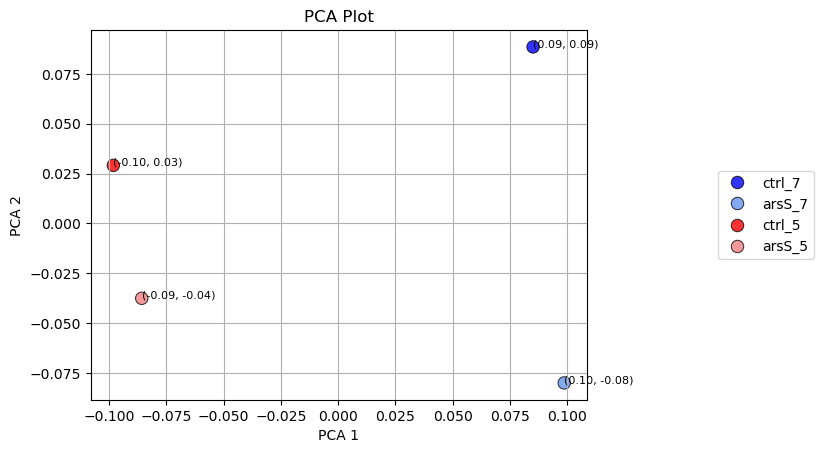

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming pca_X contains your PCA-transformed data
# Assuming freq_tss_pca contains the data for sample labels

pca_freq = sns.scatterplot(x=pca_X[:,0], y=pca_X[:,1], hue=freq_tss_pca['sample'], markers=['o','s', '^', 'H', '3', 'D'],
                           palette=['b','cornflowerblue', 'r', 'lightcoral'], s=80, alpha=0.8, ec='k')

# Add legend
pca_freq.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)

# Add labels to each point
for i in range(len(pca_X)):
    plt.text(pca_X[i, 0], pca_X[i, 1], f'({pca_X[i, 0]:.2f}, {pca_X[i, 1]:.2f})', fontsize=8)

# Add labels and title
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA Plot')

# Show plot
plt.grid(True)
plt.show()


In [41]:
pca_genes = pd.DataFrame(pca.components_, index = ['PC1', 'PC2'], columns = freq_tss_pca.drop(columns = ['sample']).columns)
pc = pca_genes.transpose()
hivar_p = pc.loc[(pc['PC1'] >= 0.11) | (pc['PC1'] <= -0.11) | (pc['PC2'] >= 0.11) | (pc['PC2'] <= -0.11)]


In [42]:
hivar_p

,PC1,PC2
gene,,
HP0147,-0.007655,0.142611
HP0163,0.324623,0.030880
HP0164,0.324623,0.030880
HP0232,0.216415,0.020587
HP0330,0.007655,-0.142611
HP0362,-0.007655,0.142611
HP0363,-0.007655,0.142611
HP0377,-0.007655,0.142611
HP0601,0.166318,-0.086748


## Promoter, Coding, and Noncoding region

In [ ]:
def classify_region(row, annot_df):
    in_promoter = new_df[(new_df['-Val'] <= row['start']) & (new_df['TSS'] >= row['start'])]
    # Check if 'start' is in any coding region
    in_coding = annot_df[(annot_df['start'] <= row['start']) & (annot_df['end'] >= row['start'])]

    if not in_promoter.empty:
        return 'promoter region'
    
    elif not in_coding.empty:
        return 'coding region'
    
    elif in_coding.empty and in_promoter.empty: 
        return 'promoter and coding region'
    # Otherwise, it's intergenic
    return 'intergenic region'

# Apply the classification function
merged['Classification'] = merged.apply(classify_region, axis=1, annot_df=annot)

merged.to_csv('genetic_regions.csv', index=False)

In [26]:
merged[merged['Classification'] == 'intergenic region']

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535,GAGG,intergenic region
225,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4360,4360,647,+,.,context=ATTATTTGAAAATAAAGCGTAGAAAATGATTTAAAAAG...,5.70,ATTATTTGAAAATAAAGCGTAGAAAATGATTTAAAAAGCAC,549,RCGDAD,603,RCGDAD,intergenic region
226,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4401,4401,625,+,.,context=TTGGTGGCGGAGCGGACGGGACTCGAACCCGCGACCCC...,4.83,TTGGTGGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTG,550,GANTC,604,GANTC,intergenic region
227,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4403,4403,430,-,.,context=CGCAGGGGGTCGCGGGTTCGAGTCCCGTCCGCTCCGCC...,3.45,CGCAGGGGGTCGCGGGTTCGAGTCCCGTCCGCTCCGCCACC,542,"TCGA,GANTC",417,"TCGA,GANTC",intergenic region
228,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,4406,4406,701,+,.,context=GGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTGCG...,5.15,GGCGGAGCGGACGGGACTCGAACCCGCGACCCCCTGCGTGA,548,TCGA,685,TCGA,intergenic region
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82703,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665614,1665614,420,+,.,context=AACACACCCGCTAACTGCACATGAATATTGCACTACAA...,3.90,AACACACCCGCTAACTGCACATGAATATTGCACTACAAATG,455,CATG,387,CATG,intergenic region
82704,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665615,1665615,456,-,.,context=GCATTTGTAGTGCAATATTCATGTGCAGTTAGCGGGTG...,3.92,GCATTTGTAGTGCAATATTCATGTGCAGTTAGCGGGTGTGT,455,CATG,461,CATG,intergenic region
82706,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665811,1665811,493,-,.,context=AAGGGTTAGAGGGTTAAAGGAGGGGGTTTCTTGTGCTA...,4.52,AAGGGTTAGAGGGTTAAAGGAGGGGGTTTCTTGTGCTAGAA,453,GAGG,496,GAGG,intergenic region
82708,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1665822,1665822,537,-,.,context=CGATAAAAAGTAAGGGTTAGAGGGTTAAAGGAGGGGGT...,4.66,CGATAAAAAGTAAGGGTTAGAGGGTTAAAGGAGGGGGTTTC,445,GAGG,515,GAGG,intergenic region


In [28]:
merged[merged['Classification'] == 'coding region']

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656,GANTC,coding region
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597,GANTC,coding region
6,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695,RCGDAD,coding region
12,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738,RCGDAD,coding region
13,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,383,383,526,+,.,context=TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATG...,4.56,TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATGCTC,525,RCGDAD,494,RCGDAD,coding region
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82780,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663,GATC,coding region
82782,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447,DGAAGG,coding region
82783,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451,RCGDAD,coding region
82784,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644,GAAGA,coding region


In [29]:
merged[merged['Classification'] == 'promoter region']

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification
146,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2630,2630,673,-,.,context=AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGA...,5.42,AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGATTT,535,RCGDAD,685,RCGDAD,promoter region
675,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,12653,12653,390,+,.,context=CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTC...,3.37,CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTCTTT,436,GAGG,360,GAGG,promoter region
718,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,13632,13632,555,+,.,context=CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTT...,5.29,CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTTTTG,426,GAGG,540,GAGG,promoter region
883,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,16817,16817,512,-,.,context=TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATG...,4.69,TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATGAAA,436,RCGDAD,441,RCGDAD,promoter region
1268,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,24287,24287,815,+,.,context=TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGA...,6.33,TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGAGTC,540,CATG,788,CATG,promoter region
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82363,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1658271,1658271,355,+,.,context=TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTAT...,3.04,TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTATAGA,467,GAAGA/TCTTC,318,TCTTC,promoter region
82458,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660072,1660072,298,-,.,context=GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTA...,2.89,GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTAACG,431,ATTAAT,341,ATTAAT,promoter region
82459,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660075,1660075,562,+,.,context=TAAACCCGTCAATGATATTAATAGCGTTACTGATACCC...,4.91,TAAACCCGTCAATGATATTAATAGCGTTACTGATACCCACC,451,ATTAAT,578,ATTAAT,promoter region
82476,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660580,1660580,485,+,.,context=TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTAC...,4.51,TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTACAAT,436,GAGG,471,GAGG,promoter region


## Attach genetic category to each methylation instance

1. Label each methylation for which gene it appears in
2. Index annotated for genetic cateogries
3. append genetic category to merged dataframe
4. plot a histogram of the categories methylation frequencies 

In [30]:
genetic_regions = pd.read_csv('genetic_regions.csv')

In [31]:
genetic_regions[genetic_regions['Classification'] == 'promoter region']

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification
98,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2630,2630,673,-,.,context=AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGA...,5.42,AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGATTT,535,RCGDAD,685.0,RCGDAD,promoter region
459,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,12653,12653,390,+,.,context=CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTC...,3.37,CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTCTTT,436,GAGG,360.0,GAGG,promoter region
488,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,13632,13632,555,+,.,context=CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTT...,5.29,CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTTTTG,426,GAGG,540.0,GAGG,promoter region
593,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,16817,16817,512,-,.,context=TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATG...,4.69,TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATGAAA,436,RCGDAD,441.0,RCGDAD,promoter region
853,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,24287,24287,815,+,.,context=TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGA...,6.33,TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGAGTC,540,CATG,788.0,CATG,promoter region
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236816,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1658271,1658271,355,+,.,context=TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTAT...,3.04,TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTATAGA,467,GAAGA/TCTTC,318.0,TCTTC,promoter region
236878,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660072,1660072,298,-,.,context=GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTA...,2.89,GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTAACG,431,ATTAAT,341.0,ATTAAT,promoter region
236879,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660075,1660075,562,+,.,context=TAAACCCGTCAATGATATTAATAGCGTTACTGATACCC...,4.91,TAAACCCGTCAATGATATTAATAGCGTTACTGATACCCACC,451,ATTAAT,578.0,ATTAAT,promoter region
236890,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660580,1660580,485,+,.,context=TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTAC...,4.51,TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTACAAT,436,GAGG,471.0,GAGG,promoter region


In [32]:
new_df

,TSS,+/- 50 TSS,Strand,Locus_tag,-Val
0,1295653,1295603,+,6S_RNA,1295603
1,2081,2131,-,HP0003,2131
2,2672,2622,+,HP0004,2622
3,2646,2696,-,HP0004,2696
4,2646,2696,-,HP0005,2696
...,...,...,...,...,...
1896,1233920,1233870,+,sRNA_Li_50,1233870
1897,1245780,1245830,-,sRNA_Li_7,1245830
1898,1209438,1209388,+,sRNA_Li_9,1209388
1899,16824,16774,+,SRP_RNA,16774


In [33]:
print(genetic_regions.columns)

Index(['sample', 'seq_id', 'source', 'type', 'start', 'end', 'score', 'strand',
       'phase', 'attributes', 'IPDRatio', 'context', 'coverage', 'id',
       'identificationQv', 'motif', 'Classification'],
      dtype='object')


In [34]:
print(new_df.columns)

Index(['TSS', '+/- 50 TSS', 'Strand', 'Locus_tag', '-Val'], dtype='object')


In [35]:
# promoter region indentifications
def update_gene_id(row, new_df):
    if row['Classification'] == 'promoter region':
        match = new_df[(new_df['-Val'] <= row['start']) & (new_df['TSS'] >= row['start'])]
        if not match.empty:
            return match['Locus_tag'].values[0]  # Replace 'gene_ID' with 'Locus_tag' or 'Name'
    return None

genetic_regions['gene_ID'] = None
genetic_regions['gene_ID'] = genetic_regions.apply(update_gene_id, axis=1, new_df=new_df)

In [36]:
genetic_regions[genetic_regions['Classification'] == 'promoter region']

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID
98,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2630,2630,673,-,.,context=AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGA...,5.42,AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGATTT,535,RCGDAD,685.0,RCGDAD,promoter region,HP0004
459,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,12653,12653,390,+,.,context=CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTC...,3.37,CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTCTTT,436,GAGG,360.0,GAGG,promoter region,HP0014
488,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,13632,13632,555,+,.,context=CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTT...,5.29,CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTTTTG,426,GAGG,540.0,GAGG,promoter region,HP0015
593,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,16817,16817,512,-,.,context=TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATG...,4.69,TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATGAAA,436,RCGDAD,441.0,RCGDAD,promoter region,HP0018
853,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,24287,24287,815,+,.,context=TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGA...,6.33,TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGAGTC,540,CATG,788.0,CATG,promoter region,HP0025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236816,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1658271,1658271,355,+,.,context=TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTAT...,3.04,TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTATAGA,467,GAAGA/TCTTC,318.0,TCTTC,promoter region,HP1578
236878,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660072,1660072,298,-,.,context=GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTA...,2.89,GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTAACG,431,ATTAAT,341.0,ATTAAT,promoter region,HP1581
236879,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660075,1660075,562,+,.,context=TAAACCCGTCAATGATATTAATAGCGTTACTGATACCC...,4.91,TAAACCCGTCAATGATATTAATAGCGTTACTGATACCCACC,451,ATTAAT,578.0,ATTAAT,promoter region,HP1581
236890,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660580,1660580,485,+,.,context=TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTAC...,4.51,TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTACAAT,436,GAGG,471.0,GAGG,promoter region,HP1581


In [37]:
# coding region
def update_gene_id(row, new_df):
    if row['Classification'] == 'coding region':
        match = annot[(annot['start'] <= row['start']) & (annot['end'] >= row['start'])]
        if not match.empty:
            return match['HP_number'].values[0]
    return row['gene_ID']

# Apply the function to update gene_id column
genetic_regions['gene_ID'] = genetic_regions.apply(update_gene_id, axis=1, new_df=new_df)

In [38]:
genetic_regions[genetic_regions['Classification'] == 'coding region']

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001
4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001
5,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,383,383,526,+,.,context=TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATG...,4.56,TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATGCTC,525,RCGDAD,494.0,RCGDAD,coding region,HP0001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,coding region,HP1589
237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,coding region,HP1589
237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,coding region,HP1589
237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,coding region,HP1590


In [39]:
gene_categories = pd.read_csv('hpy_annot - hpy_annot.csv')

In [40]:
gene_categories.rename(columns={'Unnamed: 4': 'gene_type'}, inplace=True)

In [41]:
gene_categories

,seqname,source,feature,HP_number,gene_type,start,end,Putative_Id,Orf_Size,Prot_Size(est),score,strand,frame
0,.,forsyth,gene,HP0001,TRANSCRIPTION,220,633,transcription termination factor NusB (nusB) {...,413,15180.0,.,-,.
1,.,forsyth,gene,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",638,1105,riboflavin synthase beta chain (ribE) {Haemoph...,467,17160.0,.,-,.
2,.,forsyth,gene,HP0003,CELL ENVELOPE,1118,1945,3-deoxy-d-manno-octulosonic acid 8-phosphate s...,827,30360.0,.,-,.
3,.,forsyth,gene,HP0004,CENTRAL INTERMEDIARY METABOLISM,1935,2597,carbonic anhydrase (icfA) {Synechococcus sp.},662,24310.0,.,-,.
4,.,forsyth,gene,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",2719,3399,orotidine 5'-phosphate decarboxylase (pyrF) {B...,680,24970.0,.,+,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585,.,forsyth,gene,HP1586,HYPOTHETICAL PROTEIEN,1664450,1664785,hypothetical protein,335,12320.0,.,+,.
1586,.,forsyth,gene,HP1587,HYPOTHETICAL PROTEIEN,1664880,1665344,conserved hypothetical protein {Escherichia coli},464,17050.0,.,-,.
1587,.,forsyth,gene,HP1588,HYPOTHETICAL PROTEIEN,1666032,1666790,conserved hypothetical protein {Escherichia coli},758,27830.0,.,-,.
1588,.,forsyth,gene,HP1589,HYPOTHETICAL PROTEIEN,1667060,1667680,conserved hypothetical protein {Escherichia coli},620,22770.0,.,-,.


In [42]:
genetic_regions['gene_ID'] = genetic_regions['gene_ID'].str.strip()
gene_categories['HP_number'] = gene_categories['HP_number'].str.strip()

def update_gene_type(row, gene_categories):
    match = gene_categories[gene_categories['HP_number'] == row['gene_ID']]
    if not match.empty:
        return match['gene_type'].values[0]
    return None

# Apply the function to update gene_type column
genetic_regions['gene_type'] = genetic_regions.apply(update_gene_type, axis=1, gene_categories=gene_categories)

In [43]:
genetic_regions['gene_type'] = genetic_regions['gene_type'].replace(
    'BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS,\r\nAND CARRIERS',
    'BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS'
)
genetic_regions['gene_type'] = genetic_regions['gene_type'].replace(
    'CELLULAR PROCESSE',
    'CELLULAR PROCESSES'
)
genetic_regions

,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,intergenic region,None,None
1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION
2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION
3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,coding region,HP1589,HYPOTHETICAL PROTEIEN
237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN
237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN
237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN


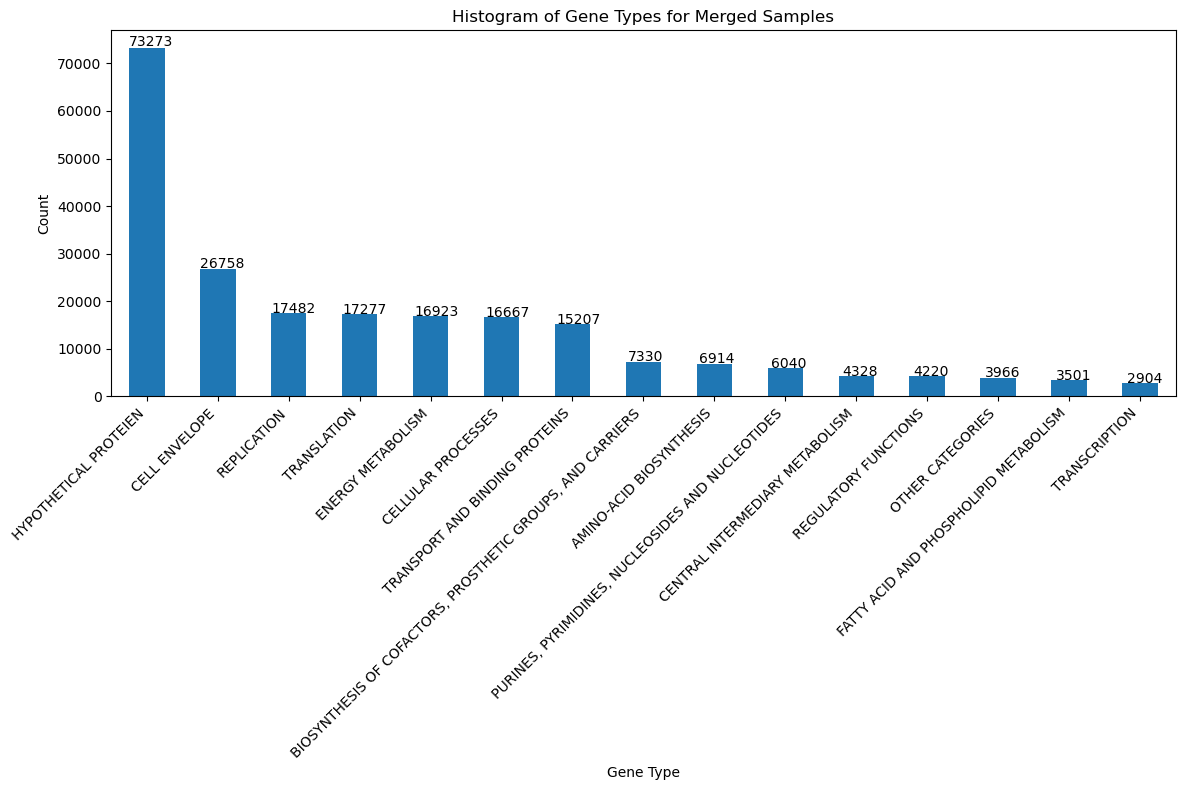

In [63]:
import matplotlib.pyplot as plt

gene_type_counts = genetic_regions['gene_type'].value_counts()

plt.figure(figsize=(12, 8))
ax = gene_type_counts.plot(kind='bar')
plt.xlabel('Gene Type')
plt.ylabel('Count')
plt.title('Histogram of Gene Types for Merged Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

# Show the plot
plt.show()

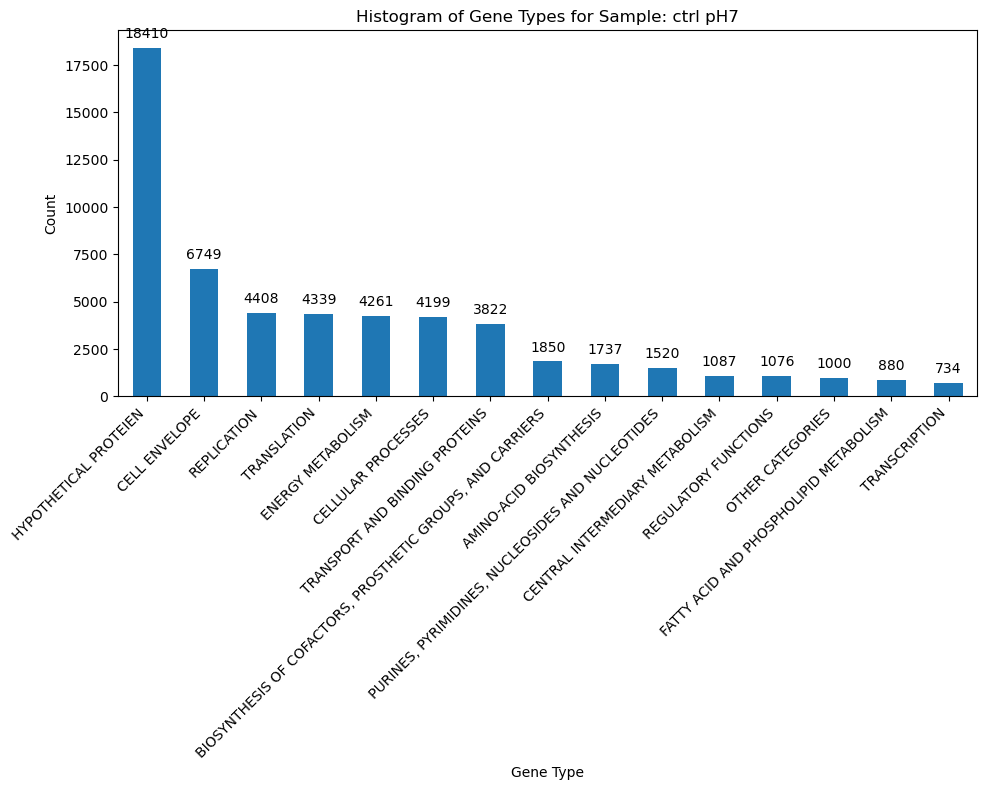

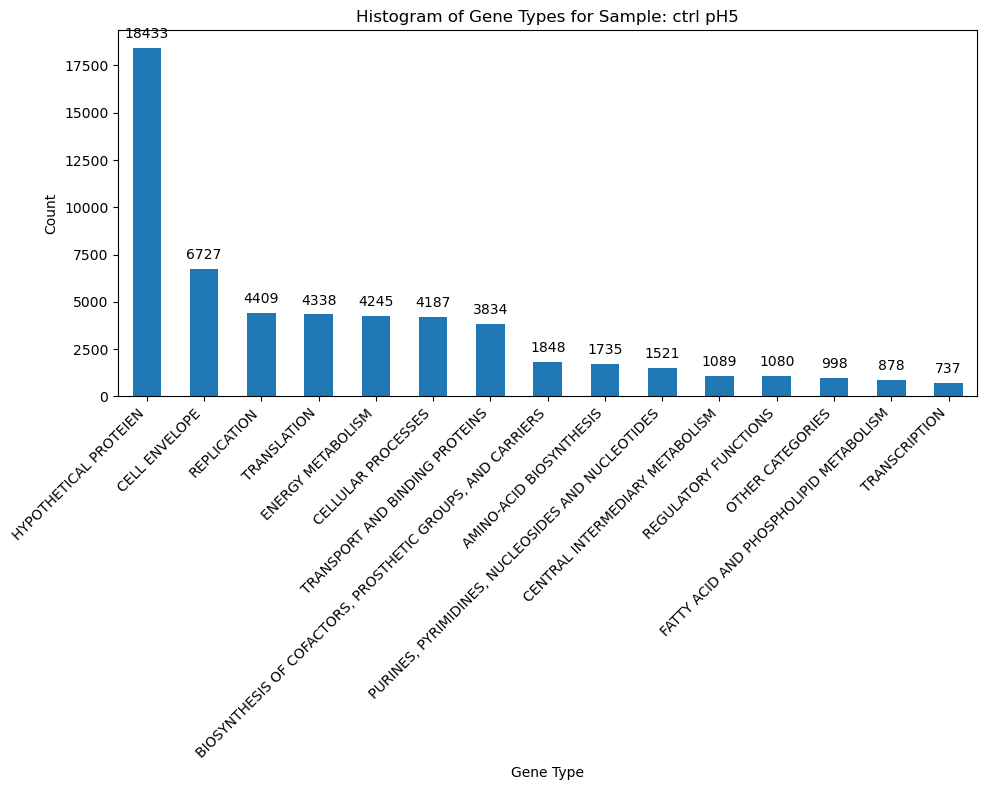

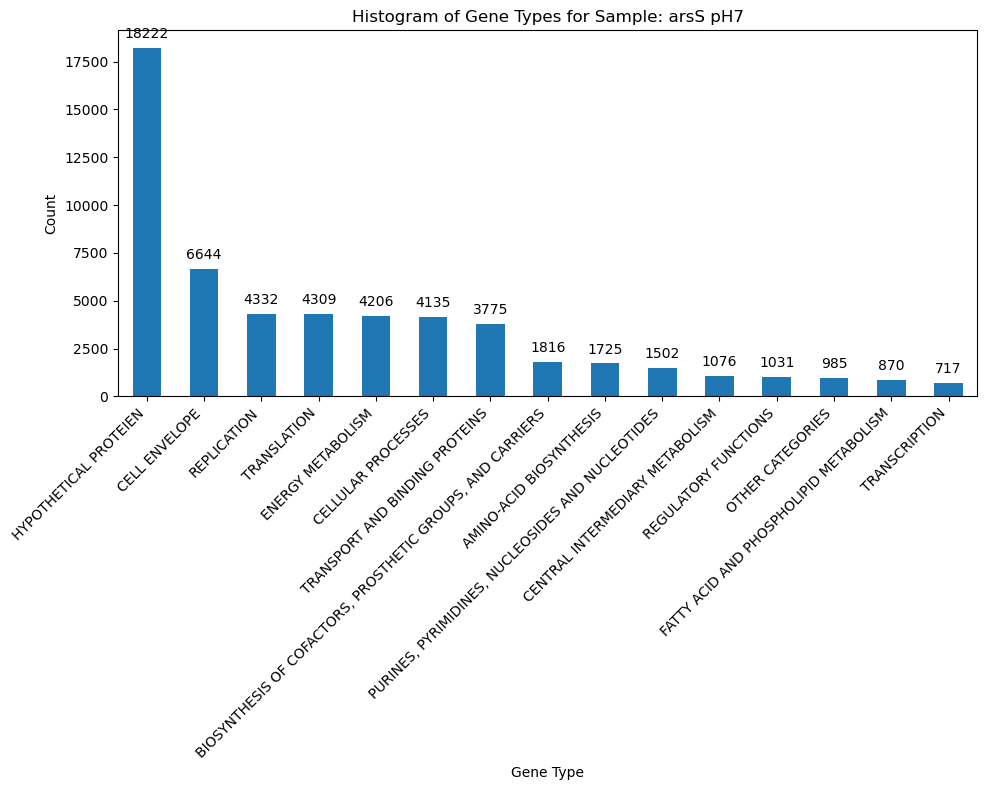

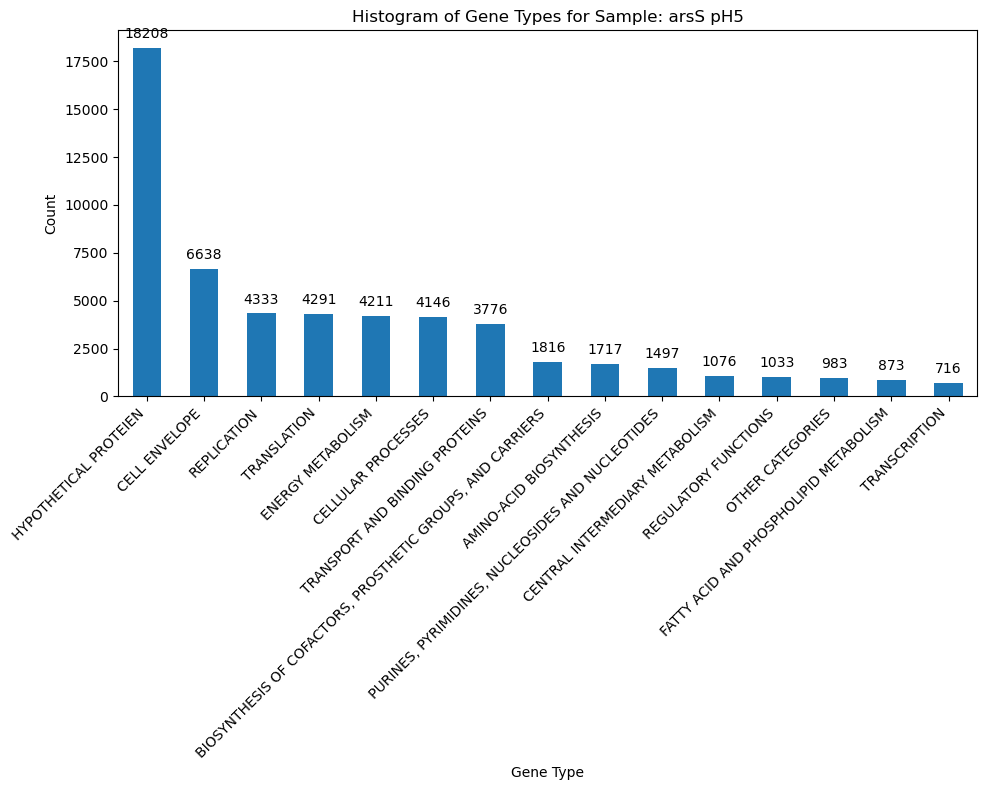

In [64]:
unique_samples = genetic_regions['sample'].unique()

# Create a histogram for each sample
for sample in unique_samples:
    sample_data = genetic_regions[genetic_regions['sample'] == sample]
    gene_type_counts = sample_data['gene_type'].value_counts()
    
    plt.figure(figsize=(10, 8))
    ax = gene_type_counts.plot(kind='bar')
    plt.xlabel('Gene Type')
    plt.ylabel('Count')
    plt.title(f'Histogram of Gene Types for Sample: {sample}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Display the counts above each bar
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    # Save the plot as an image
    plt.savefig(f'histogram_{sample}.png')
    
    # Show the plot
    plt.show()

In [65]:
gene_categories = {
    "AMINO-ACID BIOSYNTHESIS": ['HP0096', 'HP0098', 'HP0106', 'HP0107', 'HP0134', 'HP0157', 'HP0183', 'HP0212', 'HP0283', 'HP0290', 
                               'HP0330', 'HP0380', 'HP0397', 'HP0401', 'HP0510', 'HP0512', 'HP0566', 'HP0626', 'HP0649', 'HP0652', 
                               'HP0663', 'HP0672', 'HP0695', 'HP0736', 'HP0822', 'HP0941', 'HP1013', 'HP1038', 'HP1050', 'HP1158', 
                               'HP1189', 'HP1210', 'HP1229', 'HP1249', 'HP1277', 'HP1278', 'HP1279', 'HP1280', 'HP1281', 'HP1282', 
                               'HP1380', 'HP1468'],
    "BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS": ['HP0002', 'HP0006', 'HP0029', 'HP0034', 'HP0163', 'HP0172', 'HP0220', 
                                                                   'HP0237', 'HP0239', 'HP0240', 'HP0293', 'HP0306', 'HP0329', 'HP0376', 
                                                                   'HP0381', 'HP0407', 'HP0577', 'HP0587', 'HP0598', 'HP0604', 'HP0665', 
                                                                   'HP0755', 'HP0768', 'HP0769', 'HP0798', 'HP0799', 'HP0800', 'HP0801', 
                                                                   'HP0802', 'HP0804', 'HP0814', 'HP0824', 'HP0841', 'HP0843', 'HP0844', 
                                                                   'HP0845', 'HP0928', 'HP0929', 'HP0976', 'HP1036', 'HP1058', 'HP1087', 
                                                                   'HP1118', 'HP1140', 'HP1164', 'HP1224', 'HP1226', 'HP1232', 'HP1254', 
                                                                   'HP1355', 'HP1356', 'HP1360', 'HP1406', 'HP1458', 'HP1505', 'HP1545', 
                                                                   'HP1574', 'HP1582', 'HP1583'],
    "CELL ENVELOPE": ['HP0003', 'HP0009', 'HP0025', 'HP0044', 'HP0078', 'HP0079', 'HP0115', 'HP0127', 'HP0159', 'HP0173', 'HP0175', 
                      'HP0178', 'HP0180', 'HP0196', 'HP0208', 'HP0227', 'HP0229', 'HP0230', 'HP0232', 'HP0246', 'HP0252', 'HP0254', 
                      'HP0279', 'HP0289', 'HP0295', 'HP0317', 'HP0324', 'HP0325', 'HP0326', 'HP0327', 'HP0351', 'HP0352', 'HP0353', 
                      'HP0366', 'HP0379', 'HP0410', 'HP0421', 'HP0472', 'HP0477', 'HP0493', 'HP0494', 'HP0549', 'HP0567', 'HP0584', 
                      'HP0597', 'HP0601', 'HP0610', 'HP0619', 'HP0623', 'HP0638', 'HP0645', 'HP0648', 'HP0651', 'HP0655', 'HP0671', 
                      'HP0679', 'HP0684', 'HP0685', 'HP0706', 'HP0722', 'HP0725', 'HP0738', 'HP0740', 'HP0743', 'HP0751', 'HP0752', 
                      'HP0753', 'HP0770', 'HP0772', 'HP0796', 'HP0797', 'HP0805', 'HP0815', 'HP0816', 'HP0826', 'HP0830', 'HP0839', 
                      'HP0840', 'HP0855', 'HP0857', 'HP0858', 'HP0859', 'HP0867', 'HP0870', 'HP0896', 'HP0907', 'HP0908', 'HP0912', 
                      'HP0913', 'HP0922', 'HP0923', 'HP0955', 'HP0957', 'HP1030', 'HP1031', 'HP1035', 'HP1041', 'HP1052', 'HP1092', 
                      'HP1105', 'HP1107', 'HP1113', 'HP1119', 'HP1125', 'HP1155', 'HP1156', 'HP1157', 'HP1177', 'HP1191', 'HP1192', 
                      'HP1243', 'HP1274', 'HP1275', 'HP1342', 'HP1372', 'HP1373', 'HP1375', 'HP1392', 'HP1395', 'HP1416', 'HP1418', 
                      'HP1419', 'HP1420', 'HP1429', 'HP1450', 'HP1456', 'HP1462', 'HP1469', 'HP1475', 'HP1494', 'HP1501', 'HP1543', 
                      'HP1544', 'HP1557', 'HP1558', 'HP1559', 'HP1564', 'HP1565', 'HP1571', 'HP1575', 'HP1578', 'HP1581', 'HP1585'],
    "CELLULAR PROCESSES": ['HP0010', 'HP0011', 'HP0017', 'HP0019', 'HP0042', 'HP0074', 'HP0082', 'HP0099', 'HP0103', 'HP0109', 
                           'HP0110', 'HP0210', 'HP0243', 'HP0267', 'HP0286', 'HP0331', 'HP0332', 'HP0333', 'HP0355', 'HP0389', 
                           'HP0391', 'HP0392', 'HP0393', 'HP0441', 'HP0459', 'HP0517', 'HP0520', 'HP0521', 'HP0522', 'HP0523', 
                           'HP0524', 'HP0525', 'HP0526', 'HP0527', 'HP0528', 'HP0529', 'HP0530', 'HP0531', 'HP0532', 'HP0534', 
                           'HP0535', 'HP0536', 'HP0537', 'HP0538', 'HP0539', 'HP0540', 'HP0541', 'HP0542', 'HP0543', 'HP0544', 
                           'HP0545', 'HP0546', 'HP0547', 'HP0576', 'HP0599', 'HP0616', 'HP0748', 'HP0749', 'HP0763', 'HP0786', 
                           'HP0795', 'HP0875', 'HP0887', 'HP0978', 'HP0979', 'HP1006', 'HP1024', 'HP1067', 'HP1069', 'HP1086', 
                           'HP1090', 'HP1138', 'HP1152', 'HP1159', 'HP1255', 'HP1300', 'HP1332', 'HP1361', 'HP1378', 'HP1421', 
                           'HP1452', 'HP1490', 'HP1549', 'HP1550', 'HP1556', 'HP1560', 'HP1563'],
    "CENTRAL INTERMEDIARY METABOLISM": ['HP0004', 'HP0020', 'HP0047', 'HP0067', 'HP0068', 'HP0069', 'HP0070', 'HP0071', 'HP0072', 
                                        'HP0073', 'HP0075', 'HP0197', 'HP0422', 'HP0620', 'HP0696', 'HP0832', 'HP0869', 'HP0898', 
                                        'HP0899', 'HP0900', 'HP1010', 'HP1014', 'HP1186', 'HP1532'],
    "ENERGY METABOLISM": ['HP0026', 'HP0027', 'HP0037', 'HP0056', 'HP0121', 'HP0132', 'HP0144', 'HP0145', 'HP0146', 'HP0147', 
                          'HP0154', 'HP0176', 'HP0191', 'HP0192', 'HP0193', 'HP0194', 'HP0265', 'HP0277', 'HP0294', 'HP0354', 
                          'HP0357', 'HP0360', 'HP0378', 'HP0509', 'HP0574', 'HP0588', 'HP0589', 'HP0590', 'HP0591', 'HP0631', 
                          'HP0632', 'HP0633', 'HP0634', 'HP0642', 'HP0666', 'HP0691', 'HP0692', 'HP0723', 'HP0779', 'HP0828', 
                          'HP0903', 'HP0904', 'HP0905', 'HP0921', 'HP0943', 'HP0954', 'HP0961', 'HP0974', 'HP1088', 'HP1099', 
                          'HP1100', 'HP1101', 'HP1102', 'HP1103', 'HP1108', 'HP1109', 'HP1110', 'HP1111', 'HP1131', 'HP1132', 
                          'HP1133', 'HP1134', 'HP1135', 'HP1136', 'HP1137', 'HP1161', 'HP1166', 'HP1212', 'HP1222', 'HP1227', 
                          'HP1238', 'HP1260', 'HP1261', 'HP1262', 'HP1263', 'HP1266', 'HP1267', 'HP1268', 'HP1269', 'HP1270', 
                          'HP1271', 'HP1272', 'HP1273', 'HP1325', 'HP1345', 'HP1346', 'HP1385', 'HP1386', 'HP1398', 'HP1399', 
                          'HP1461', 'HP1495', 'HP1508', 'HP1538', 'HP1539', 'HP1540'],
    "FATTY ACID AND PHOSPHOLIPID METABOLISM": ['HP0090', 'HP0195', 'HP0201', 'HP0202', 'HP0215', 'HP0370', 'HP0371', 'HP0416', 
                                               'HP0499', 'HP0557', 'HP0558', 'HP0559', 'HP0561', 'HP0690', 'HP0700', 'HP0808', 
                                               'HP0871', 'HP0950', 'HP0962', 'HP1016', 'HP1045', 'HP1071', 'HP1348', 'HP1357', 
                                               'HP1376'],
    "HYPOTHETICAL PROTEIEN": ['HP0007', 'HP0008', 'HP0013', 'HP0014', 'HP0015', 'HP0016', 'HP0018', 'HP0021', 'HP0022', 'HP0024', 
                              'HP0028', 'HP0030', 'HP0031', 'HP0032', 'HP0035', 'HP0036', 'HP0038', 'HP0039', 'HP0040', 'HP0041', 
                              'HP0049', 'HP0052', 'HP0053', 'HP0057', 'HP0058', 'HP0059', 'HP0060', 'HP0061', 'HP0062', 'HP0063', 
                              'HP0064', 'HP0065', 'HP0080', 'HP0081', 'HP0085', 'HP0086', 'HP0087', 'HP0089', 'HP0093', 'HP0094', 
                              'HP0095', 'HP0097', 'HP0100', 'HP0101', 'HP0102', 'HP0105', 'HP0108', 'HP0111', 'HP0112', 'HP0113', 
                              'HP0114', 'HP0117', 'HP0118', 'HP0119', 'HP0120', 'HP0122', 'HP0129', 'HP0130', 'HP0131', 'HP0135', 
                              'HP0136', 'HP0137', 'HP0138', 'HP0139', 'HP0148', 'HP0149', 'HP0150', 'HP0151', 'HP0152', 'HP0155', 
                              'HP0156', 'HP0158', 'HP0160', 'HP0162', 'HP0165', 'HP0167', 'HP0168', 'HP0170', 'HP0174', 'HP0181', 
                              'HP0184', 'HP0185', 'HP0186', 'HP0187', 'HP0188', 'HP0189', 'HP0190', 'HP0199', 'HP0203', 'HP0204', 
                              'HP0205', 'HP0206', 'HP0207', 'HP0209', 'HP0211', 'HP0216', 'HP0217', 'HP0218', 'HP0219', 'HP0221', 
                              'HP0222', 'HP0225', 'HP0226', 'HP0228', 'HP0231', 'HP0233', 'HP0234', 'HP0235', 'HP0236', 'HP0241', 
                              'HP0242', 'HP0245', 'HP0248', 'HP0249', 'HP0253', 'HP0256', 'HP0257', 'HP0258', 'HP0261', 'HP0262', 
                              'HP0268', 'HP0269', 'HP0270', 'HP0271', 'HP0272', 'HP0273', 'HP0274', 'HP0276', 'HP0282', 'HP0284', 
                              'HP0285', 'HP0287', 'HP0288', 'HP0291', 'HP0292', 'HP0303', 'HP0304', 'HP0305', 'HP0307', 'HP0308', 
                              'HP0309', 'HP0310', 'HP0311', 'HP0314', 'HP0316', 'HP0318', 'HP0320', 'HP0322', 'HP0328', 'HP0334', 
                              'HP0335', 'HP0336', 'HP0337', 'HP0338', 'HP0339', 'HP0340', 'HP0341', 'HP0342', 'HP0343', 'HP0344', 
                              'HP0345', 'HP0346', 'HP0347', 'HP0350', 'HP0356', 'HP0358', 'HP0359', 'HP0362', 'HP0365', 'HP0367', 
                              'HP0368', 'HP0369', 'HP0373', 'HP0374', 'HP0375', 'HP0377', 'HP0383', 'HP0384', 'HP0385', 'HP0386', 
                              'HP0388', 'HP0390', 'HP0394', 'HP0395', 'HP0396', 'HP0398', 'HP0405', 'HP0406', 'HP0408', 'HP0411', 
                              'HP0415', 'HP0418', 'HP0419', 'HP0420', 'HP0423', 'HP0424', 'HP0425', 'HP0426', 'HP0427', 'HP0429', 
                              'HP0430', 'HP0431', 'HP0432', 'HP0433', 'HP0434', 'HP0435', 'HP0436', 'HP0439', 'HP0442', 'HP0443', 
                              'HP0444', 'HP0445', 'HP0446', 'HP0447', 'HP0448', 'HP0449', 'HP0450', 'HP0451', 'HP0452', 'HP0453', 
                              'HP0454', 'HP0455', 'HP0456', 'HP0457', 'HP0460', 'HP0465', 'HP0466', 'HP0467', 'HP0468', 'HP0469', 
                              'HP0479', 'HP0480', 'HP0482', 'HP0484', 'HP0485', 'HP0486', 'HP0487', 'HP0488', 'HP0489', 'HP0492', 
                              'HP0495', 'HP0496', 'HP0502', 'HP0503', 'HP0504', 'HP0505', 'HP0506', 'HP0507', 'HP0508', 'HP0511', 
                              'HP0513', 'HP0518', 'HP0519', 'HP0533', 'HP0552', 'HP0553', 'HP0554', 'HP0555', 'HP0556', 'HP0560', 
                              'HP0563', 'HP0564', 'HP0565', 'HP0568', 'HP0569', 'HP0571', 'HP0573', 'HP0575', 'HP0578', 'HP0579', 
                              'HP0580', 'HP0582', 'HP0583', 'HP0586', 'HP0594', 'HP0595', 'HP0596', 'HP0603', 'HP0605', 'HP0608', 
                              'HP0609', 'HP0611', 'HP0612', 'HP0614', 'HP0622', 'HP0624', 'HP0625', 'HP0627', 'HP0628', 'HP0629', 
                              'HP0635', 'HP0636', 'HP0637', 'HP0639', 'HP0641', 'HP0644', 'HP0647', 'HP0650', 'HP0654', 'HP0656', 
                              'HP0658', 'HP0659', 'HP0660', 'HP0664', 'HP0667', 'HP0668', 'HP0669', 'HP0670', 'HP0673', 'HP0674', 
                              'HP0677', 'HP0678', 'HP0681', 'HP0682', 'HP0688', 'HP0689', 'HP0693', 'HP0694', 'HP0697', 'HP0699', 
                              'HP0702', 'HP0704', 'HP0707', 'HP0708', 'HP0709', 'HP0710', 'HP0711', 'HP0712', 'HP0713', 'HP0716', 
                              'HP0718', 'HP0719', 'HP0720', 'HP0721', 'HP0726', 'HP0728', 'HP0729', 'HP0730', 'HP0731', 'HP0732', 
                              'HP0733', 'HP0734', 'HP0737', 'HP0741', 'HP0744', 'HP0745', 'HP0746', 'HP0747', 'HP0750', 'HP0754', 
                              'HP0756', 'HP0758', 'HP0759', 'HP0760', 'HP0761', 'HP0762', 'HP0764', 'HP0765', 'HP0766', 'HP0767', 
                              'HP0771', 'HP0773', 'HP0776', 'HP0778', 'HP0780', 'HP0781', 'HP0782', 'HP0783', 'HP0784', 'HP0785', 
                              'HP0787', 'HP0788', 'HP0789', 'HP0803', 'HP0806', 'HP0809', 'HP0810', 'HP0811', 'HP0812', 'HP0813', 
                              'HP0817', 'HP0820', 'HP0823', 'HP0833', 'HP0834', 'HP0836', 'HP0837', 'HP0838', 'HP0842', 'HP0847', 
                              'HP0849', 'HP0851', 'HP0852', 'HP0856', 'HP0860', 'HP0861', 'HP0862', 'HP0863', 'HP0864', 'HP0868', 
                              'HP0872', 'HP0873', 'HP0874', 'HP0878', 'HP0879', 'HP0880', 'HP0882', 'HP0884', 'HP0890', 'HP0891', 
                              'HP0892', 'HP0893', 'HP0894', 'HP0895', 'HP0897', 'HP0901', 'HP0902', 'HP0906', 'HP0909', 'HP0914', 
                              'HP0917', 'HP0918', 'HP0920', 'HP0926', 'HP0931', 'HP0933', 'HP0932', 'HP0934', 'HP0935', 'HP0937', 
                              'HP0938', 'HP0945', 'HP0946', 'HP0947', 'HP0948', 'HP0949', 'HP0951', 'HP0952', 'HP0953', 'HP0956', 
                              'HP0958', 'HP0959', 'HP0963', 'HP0964', 'HP0965', 'HP0966', 'HP0971', 'HP0973', 'HP0975', 'HP0977', 
                              'HP0980', 'HP0981', 'HP0982', 'HP0983', 'HP0984', 'HP0985', 'HP0986', 'HP0987', 'HP0990', 'HP0991', 
                              'HP0992', 'HP0993', 'HP0994', 'HP0996', 'HP0999', 'HP1001', 'HP1002', 'HP1003', 'HP1004', 'HP1005', 
                              'HP1015', 'HP1018', 'HP1020', 'HP1022', 'HP1023', 'HP1026', 'HP1028', 'HP1029', 'HP1033', 'HP1037', 
                              'HP1039', 'HP1042', 'HP1044', 'HP1046', 'HP1049', 'HP1051', 'HP1053', 'HP1054', 'HP1055', 'HP1056', 
                              'HP1057', 'HP1060', 'HP1061', 'HP1064', 'HP1065', 'HP1066', 'HP1070', 'HP1074', 'HP1075', 'HP1076', 
                              'HP1078', 'HP1079', 'HP1080', 'HP1081', 'HP1083', 'HP1085', 'HP1089', 'HP1094', 'HP1097', 'HP1098', 
                              'HP1104', 'HP1106', 'HP1115', 'HP1116', 'HP1117', 'HP1120', 'HP1122', 'HP1124', 'HP1127', 'HP1128', 
                              'HP1142', 'HP1143', 'HP1144', 'HP1145', 'HP1146', 'HP1149', 'HP1150', 'HP1154', 'HP1160', 'HP1162', 
                              'HP1163', 'HP1167', 'HP1173', 'HP1175', 'HP1182', 'HP1184', 'HP1185', 'HP1187', 'HP1188', 'HP1193', 
                              'HP1194', 'HP1207', 'HP1211', 'HP1214', 'HP1215', 'HP1216', 'HP1217', 'HP1219', 'HP1221', 'HP1223', 
                              'HP1225', 'HP1230', 'HP1233', 'HP1234', 'HP1235', 'HP1236', 'HP1239', 'HP1240', 'HP1242', 'HP1247', 
                              'HP1250', 'HP1258', 'HP1259', 'HP1264', 'HP1265', 'HP1276', 'HP1283', 'HP1284', 'HP1285', 'HP1286', 
                              'HP1288', 'HP1289', 'HP1291', 'HP1322', 'HP1324', 'HP1326', 'HP1327', 'HP1330', 'HP1331', 'HP1333', 
                              'HP1334', 'HP1335', 'HP1336', 'HP1337', 'HP1338', 'HP1343', 'HP1349', 'HP1351', 'HP1353', 'HP1354', 
                              'HP1358', 'HP1359', 'HP1363', 'HP1377', 'HP1381', 'HP1382', 'HP1384', 'HP1388', 'HP1389', 'HP1390', 
                              'HP1391', 'HP1394', 'HP1396', 'HP1397', 'HP1401', 'HP1407', 'HP1408', 'HP1409', 'HP1410', 'HP1411', 
                              'HP1412', 'HP1413', 'HP1414', 'HP1417', 'HP1423', 'HP1424', 'HP1425', 'HP1426', 'HP1428', 'HP1433', 
                              'HP1436', 'HP1437', 'HP1438', 'HP1439', 'HP1440', 'HP1443', 'HP1449', 'HP1451', 'HP1453', 'HP1454', 
                              'HP1455', 'HP1457', 'HP1459', 'HP1463', 'HP1464', 'HP1466', 'HP1467', 'HP1473', 'HP1477', 'HP1479', 
                              'HP1481', 'HP1482', 'HP1484', 'HP1486', 'HP1487', 'HP1488', 'HP1489', 'HP1493', 'HP1492', 'HP1498', 
                              'HP1499', 'HP1500', 'HP1502', 'HP1504', 'HP1507', 'HP1509', 'HP1510', 'HP1511', 'HP1516', 'HP1518', 
                              'HP1519', 'HP1520', 'HP1524', 'HP1525', 'HP1527', 'HP1531', 'HP1533', 'HP1536', 'HP1537', 'HP1542', 
                              'HP1546', 'HP1548', 'HP1551', 'HP1566', 'HP1567', 'HP1568', 'HP1569', 'HP1570', 'HP1573', 'HP1579', 
                              'HP1580', 'HP1586', 'HP1587', 'HP1588', 'HP1589', 'HP1590'],
    "OTHER CATEGORIES": ['HP0280', 'HP0315', 'HP0413', 'HP0414', 'HP0428', 'HP0437', 'HP0438', 'HP0606', 'HP0630', 'HP0739', 
                         'HP0827', 'HP0885', 'HP0924', 'HP0927', 'HP0930', 'HP0967', 'HP0970', 'HP0988', 'HP0989', 'HP0997', 
                         'HP0998', 'HP1000', 'HP1007', 'HP1008', 'HP1034', 'HP1095', 'HP1096', 'HP1126', 'HP1139', 'HP1165', 
                         'HP1228', 'HP1248', 'HP1431', 'HP1444', 'HP1476', 'HP1483', 'HP1496', 'HP1534', 'HP1535'],
    "PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES": ['HP0005', 'HP0043', 'HP0045', 'HP0104', 'HP0198', 'HP0255', 'HP0266', 
                                                          'HP0321', 'HP0349', 'HP0364', 'HP0372', 'HP0409', 'HP0572', 'HP0581', 
                                                          'HP0618', 'HP0646', 'HP0680', 'HP0683', 'HP0735', 'HP0742', 'HP0757', 
                                                          'HP0777', 'HP0825', 'HP0829', 'HP0854', 'HP0865', 'HP0919', 'HP1011', 
                                                          'HP1084', 'HP1112', 'HP1178', 'HP1179', 'HP1218', 'HP1237', 'HP1257', 
                                                          'HP1434', 'HP1474', 'HP1530'],
    "REGULATORY FUNCTIONS": ['HP0048', 'HP0088', 'HP0164', 'HP0166', 'HP0224', 'HP0244', 'HP0278', 'HP0400', 'HP0703', 'HP0714', 
                             'HP0727', 'HP0775', 'HP0792', 'HP1021', 'HP1025', 'HP1027', 'HP1032', 'HP1043', 'HP1168', 'HP1287', 
                             'HP1364', 'HP1365', 'HP1442', 'HP1572'],
    "REPLICATION": ['HP0012', 'HP0050', 'HP0051', 'HP0054', 'HP0091', 'HP0092', 'HP0116', 'HP0142', 'HP0153', 'HP0213', 'HP0259', 
                    'HP0260', 'HP0263', 'HP0275', 'HP0323', 'HP0348', 'HP0387', 'HP0440', 'HP0462', 'HP0463', 'HP0464', 'HP0478', 
                    'HP0481', 'HP0483', 'HP0500', 'HP0501', 'HP0548', 'HP0585', 'HP0592', 'HP0593', 'HP0602', 'HP0615', 'HP0621', 
                    'HP0661', 'HP0675', 'HP0676', 'HP0701', 'HP0705', 'HP0717', 'HP0790', 'HP0821', 'HP0846', 'HP0848', 'HP0850', 
                    'HP0877', 'HP0883', 'HP0910', 'HP0911', 'HP0925', 'HP0995', 'HP1009', 'HP1059', 'HP1063', 'HP1114', 'HP1121', 
                    'HP1208', 'HP1209', 'HP1231', 'HP1245', 'HP1323', 'HP1347', 'HP1352', 'HP1362', 'HP1366', 'HP1367', 'HP1368', 
                    'HP1369', 'HP1370', 'HP1371', 'HP1383', 'HP1387', 'HP1393', 'HP1402', 'HP1403', 'HP1404', 'HP1460', 'HP1470', 
                    'HP1471', 'HP1472', 'HP1478', 'HP1517', 'HP1521', 'HP1522', 'HP1523', 'HP1526', 'HP1529', 'HP1541', 'HP1553'],
    "TRANSCRIPTION": ['HP0001', 'HP0550', 'HP0640', 'HP0662', 'HP0866', 'HP1198', 'HP1203', 'HP1213', 'HP1293', 'HP1514'],
"TRANSLATION": ['HP0033', 'HP0076', 'HP0077', 'HP0083', 'HP0084', 'HP0123', 'HP0124', 'HP0125', 'HP0126', 'HP0169', 'HP0171', 
                    'HP0177', 'HP0182', 'HP0200', 'HP0223', 'HP0238', 'HP0247', 'HP0264', 'HP0281', 'HP0296', 'HP0297', 'HP0319', 
                    'HP0361', 'HP0363', 'HP0382', 'HP0399', 'HP0402', 'HP0403', 'HP0404', 'HP0417', 'HP0470', 'HP0476', 'HP0491', 
                    'HP0514', 'HP0515', 'HP0516', 'HP0551', 'HP0562', 'HP0570', 'HP0617', 'HP0643', 'HP0657', 'HP0774', 'HP0793', 
                    'HP0794', 'HP0835', 'HP0886', 'HP0944', 'HP0960', 'HP0972', 'HP1012', 'HP1019', 'HP1040', 'HP1047', 'HP1048', 
                    'HP1062', 'HP1068', 'HP1123', 'HP1141', 'HP1147', 'HP1148', 'HP1151', 'HP1153', 'HP1190', 'HP1195', 'HP1196', 
                    'HP1197', 'HP1199', 'HP1200', 'HP1201', 'HP1202', 'HP1204', 'HP1205', 'HP1241', 'HP1244', 'HP1246', 'HP1253', 
                    'HP1256', 'HP1292', 'HP1294', 'HP1295', 'HP1296', 'HP1297', 'HP1298', 'HP1299', 'HP1301', 'HP1302', 'HP1303', 
                    'HP1304', 'HP1305', 'HP1306', 'HP1307', 'HP1308', 'HP1309', 'HP1310', 'HP1311', 'HP1312', 'HP1313', 'HP1314', 
                    'HP1315', 'HP1316', 'HP1317', 'HP1318', 'HP1319', 'HP1320', 'HP1350', 'HP1374', 'HP1379', 'HP1415', 'HP1422', 
                    'HP1435', 'HP1441', 'HP1447', 'HP1448', 'HP1480', 'HP1485', 'HP1497', 'HP1513', 'HP1547', 'HP1554', 'HP1555', 
                    'HP1584'],
    "TRANSPORT AND BINDING PROTEINS": ['HP0055', 'HP0133', 'HP0140', 'HP0141', 'HP0143', 'HP0179', 'HP0214', 'HP0250', 'HP0251', 
                                       'HP0298', 'HP0299', 'HP0300', 'HP0301', 'HP0302', 'HP0313', 'HP0471', 'HP0473', 'HP0474', 
                                       'HP0475', 'HP0490', 'HP0497', 'HP0498', 'HP0600', 'HP0607', 'HP0613', 'HP0653', 'HP0686', 
                                       'HP0687', 'HP0715', 'HP0724', 'HP0791', 'HP0807', 'HP0818', 'HP0819', 'HP0853', 'HP0876', 
                                       'HP0888', 'HP0889', 'HP0915', 'HP0916', 'HP0936', 'HP0939', 'HP0940', 'HP0942', 'HP0969', 
                                       'HP1017', 'HP1072', 'HP1073', 'HP1077', 'HP1082', 'HP1091', 'HP1129', 'HP1130', 'HP1169', 
                                       'HP1170', 'HP1171', 'HP1172', 'HP1174', 'HP1180', 'HP1181', 'HP1183', 'HP1206', 'HP1220', 
                                       'HP1251', 'HP1252', 'HP1290', 'HP1328', 'HP1329', 'HP1339', 'HP1340', 'HP1341', 'HP1344', 
                                       'HP1400', 'HP1427', 'HP1432', 'HP1445', 'HP1446', 'HP1465', 'HP1491', 'HP1503', 'HP1506', 
                                       'HP1512', 'HP1552', 'HP1561', 'HP1562', 'HP1576', 'HP1577']
}


In [66]:
category_lengths = []
for category, genes in gene_categories.items():
    total_length = annot[annot['HP_number'].isin(genes)]['Orf_Size'].sum()
    category_lengths.append({'Category': category, 'Total_Length': total_length})

In [68]:
category_lengths_df = pd.DataFrame(category_lengths)
category_lengths_df

,Category,Total_Length
0,AMINO-ACID BIOSYNTHESIS,45069
1,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",52381
2,CELL ENVELOPE,185198
3,CELLULAR PROCESSES,108069
4,CENTRAL INTERMEDIARY METABOLISM,24081
5,ENERGY METABOLISM,102025
6,FATTY ACID AND PHOSPHOLIPID METABOLISM,21020
7,HYPOTHETICAL PROTEIEN,510597
8,OTHER CATEGORIES,30491
9,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",39742


In [74]:
plt.figure(figsize=(12, 10))
ax = genetic_regions.set_index('gene_type')['adjusted_count'].plot(kind='bar')
plt.xlabel('Gene Type')
plt.ylabel('Count / Total Length')
plt.title('Control pH 7 Frequency Per Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.6f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

KeyError: 'adjusted_count'

<Figure size 1200x1000 with 0 Axes>

In [44]:
genetic_regions.to_csv('merged_final.csv')

## Adding MTASEs

In [71]:
promoter = genetic_regions[genetic_regions['Classification'] == 'promoter region']

In [72]:
gene_ids = [
    "HP0080", "HP0110", "HP0270", "HP0306", "HP0407", "HP0547",
    "HP0554", "HP0775", "HP0777", "HP0914", "HP0966", "HP1039",
    "HP1137", "HP1142", "HP1271", "HP1373", "HP1530", "HP1531"
]

In [73]:
promoter_ctrl7 = promoter[promoter['sample'] == 'ctrl pH7']
hyper_ctrl7_p = promoter_ctrl7[promoter_ctrl7['gene_ID'].isin(gene_ids)]
hyper_ctrl7_p['motif'].value_counts()

motif
CATG                   68
GATC                   43
GANTC                  27
TCTTC                  19
GAAGA                  15
RCGDAD                 13
GAGG                   10
ATTAAT                 10
GCAG                   10
CTANNNNNNNNTGT          3
RCGDAD,GATC             3
YCGRATD                 2
DGAAGG                  2
ACANNNNNNNNTAG          2
HHTCAVNNNNNNTGY         1
ACANNNNNNNNTAG,CATG     1
GAAGA,GATC              1
YCGAATC                 1
TCGA,GANTC              1
TCGA,GATC               1
GAGG,GAAGA              1
GAAGA,GANTC             1
Name: count, dtype: int64

In [74]:
promoter_ctrl5 = promoter[promoter['sample'] == 'ctrl pH5']
hyper_ctrl5_p = promoter_ctrl5[promoter_ctrl5['gene_ID'].isin(gene_ids)]
hyper_ctrl5_p['motif'].value_counts()

motif
CATG                   68
GATC                   43
GANTC                  27
TCTTC                  19
GAAGA                  15
RCGDAD                 13
GAGG                   11
ATTAAT                 10
GCAG                   10
CTANNNNNNNNTGT          3
RCGDAD,GATC             3
HTCAVNNNNNNTGY          2
DGAAGG                  2
ACANNNNNNNNTAG          2
YCGRATD                 2
ACANNNNNNNNTAG,CATG     1
GAAGA,GATC              1
YCGAATC                 1
TCGA,GANTC              1
TCGA,GATC               1
GAGG,GAAGA              1
GAAGA,GANTC             1
Name: count, dtype: int64

In [75]:
promoter_ars7 = promoter[promoter['sample'] == 'arsS pH7']
hyper_ars7_p = promoter_ars7[promoter_ars7['gene_ID'].isin(gene_ids)]
hyper_ars7_p['motif'].value_counts()

motif
CATG                   68
GATC                   43
GANTC                  27
TCTTC                  19
GAAGA                  15
RCGDAD                 13
ATTAAT                 10
GCAG                   10
GAGG                   10
CTANNNNNNNNTGT          3
RCGDAD,GATC             3
DGAAGG                  2
ACANNNNNNNNTAG          2
YCGRATD                 2
ACANNNNNNNNTAG,CATG     1
GAAGA,GATC              1
YCGAATC                 1
TCGA,GANTC              1
TCGA,GATC               1
GAGG,GAAGA              1
GAAGA,GANTC             1
Name: count, dtype: int64

In [76]:
promoter_ars5 = promoter[promoter['sample'] == 'arsS pH5']
hyper_ars5_p = promoter_ars5[promoter_ars5['gene_ID'].isin(gene_ids)]
hyper_ars5_p['motif'].value_counts()

motif
CATG                   68
GATC                   43
GANTC                  27
TCTTC                  19
GAAGA                  15
RCGDAD                 13
GAGG                   11
ATTAAT                 10
GCAG                   10
CTANNNNNNNNTGT          3
RCGDAD,GATC             3
DGAAGG                  2
ACANNNNNNNNTAG          2
YCGRATD                 2
ACANNNNNNNNTAG,CATG     1
GAAGA,GATC              1
YCGAATC                 1
TCGA,GANTC              1
TCGA,GATC               1
GAGG,GAAGA              1
GAAGA,GANTC             1
Name: count, dtype: int64

In [77]:
hyper_ctrl7_p

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
2984,2984,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,84938,84938,367,+,.,context=GCATGTATGGAATGTATGGCATGGGCATGTATGATTTT...,3.09,GCATGTATGGAATGTATGGCATGGGCATGTATGATTTTTAT,511,CATG,345.0,CATG,promoter region,HP0080,HYPOTHETICAL PROTEIEN
2985,2985,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,84939,84939,581,-,.,context=CATAAAAATCATACATGCCCATGCCATACATTCCATAC...,4.45,CATAAAAATCATACATGCCCATGCCATACATTCCATACATG,508,CATG,557.0,CATG,promoter region,HP0080,HYPOTHETICAL PROTEIEN
2986,2986,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,84944,84944,432,+,.,context=ATGGAATGTATGGCATGGGCATGTATGATTTTTATGAC...,3.49,ATGGAATGTATGGCATGGGCATGTATGATTTTTATGACTTT,509,CATG,405.0,CATG,promoter region,HP0080,HYPOTHETICAL PROTEIEN
2987,2987,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,84945,84945,440,-,.,context=AAAAGTCATAAAAATCATACATGCCCATGCCATACATT...,3.59,AAAAGTCATAAAAATCATACATGCCCATGCCATACATTCCA,504,CATG,512.0,CATG,promoter region,HP0080,HYPOTHETICAL PROTEIEN
2988,2988,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,84974,84974,455,+,.,context=TTTATGACTTTTATGATGGCATGTATGGATTCTACCCT...,3.70,TTTATGACTTTTATGATGGCATGTATGGATTCTACCCTAAC,504,CATG,409.0,CATG,promoter region,HP0080,HYPOTHETICAL PROTEIEN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57519,57519,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1609789,1609789,444,+,.,context=AATACGCAAGATTTTAGCGGATATTGAAGATTCGCAAA...,3.95,AATACGCAAGATTTTAGCGGATATTGAAGATTCGCAAAATG,402,RCGDAD,480.0,RCGDAD,promoter region,HP1530,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
57520,57520,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1609797,1609797,274,-,.,context=TTCAATTTCATTTTGCGAATCTTCAATATCCGCTAAAA...,2.81,TTCAATTTCATTTTGCGAATCTTCAATATCCGCTAAAATCT,389,GAAGA/TCTTC,335.0,TCTTC,promoter region,HP1530,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
57521,57521,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1609798,1609798,473,+,.,context=GATTTTAGCGGATATTGAAGATTCGCAAAATGAAATTG...,4.43,GATTTTAGCGGATATTGAAGATTCGCAAAATGAAATTGAAA,410,"GAAGA/TCTTC,GANTC",437.0,"GAAGA,GANTC",promoter region,HP1530,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
57522,57522,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1609799,1609799,501,-,.,context=ATTTCAATTTCATTTTGCGAATCTTCAATATCCGCTAA...,5.30,ATTTCAATTTCATTTTGCGAATCTTCAATATCCGCTAAAAT,401,RCGDAD,406.0,RCGDAD,promoter region,HP1530,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"


In [78]:
hyper_ctrl7_p[hyper_ctrl7_p['motif'].isna()]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
10242,10242,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,280484,280484,130,-,.,coverage=464;context=CAAATTGATCCCAAGTGTTCAACCG...,2.20,CAAATTGATCCCAAGTGTTCAACCGCCATGCGTTTTTACAA,464,NaN,102.0,NaN,promoter region,HP0270,HYPOTHETICAL PROTEIEN
15218,15218,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,419069,419069,162,+,.,coverage=437;context=GTGTTTTAACAGAATGCAAGCTTGA...,2.24,GTGTTTTAACAGAATGCAAGCTTGAAGGAGAATCATGTCCA,437,NaN,17.0,NaN,promoter region,HP0407,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ..."
21028,21028,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,588701,588701,135,+,.,coverage=456;context=CTATATTGAGCGTAAAAATGCGAAG...,2.15,CTATATTGAGCGTAAAAATGCGAAGAGATTTTGATTCGCTC,456,NaN,55.0,NaN,promoter region,HP0554,HYPOTHETICAL PROTEIEN
29788,29788,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,828462,828462,187,+,.,coverage=482;context=ATCCATGTCTTCAAAAACAGAGCGC...,2.47,ATCCATGTCTTCAAAAACAGAGCGCCCAAAAAAAGTCGCTA,482,NaN,142.0,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
29789,29789,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,828467,828467,246,-,.,coverage=483;context=TATCTTAGCGACTTTTTTTGGGCGC...,2.98,TATCTTAGCGACTTTTTTTGGGCGCTCTGTTTTTGAAGACA,483,NaN,NaN,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
29910,29910,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,831084,831084,166,+,.,coverage=456;context=ACCTAATCTTGCTTAAAAACACCCT...,2.29,ACCTAATCTTGCTTAAAAACACCCTTTCTGAATTTTAAGCC,456,NaN,113.0,NaN,promoter region,HP0777,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES"
36829,36829,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1025294,1025294,132,+,.,coverage=471;context=GATCCCACAGCCACGCTAGAATATT...,2.12,GATCCCACAGCCACGCTAGAATATTCTTCTTCTAAATTAGC,471,NaN,9.0,NaN,promoter region,HP0966,HYPOTHETICAL PROTEIEN
42893,42893,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1203777,1203777,204,+,.,coverage=475;context=TGAATACGATAAAATTTTTCATCTT...,2.88,TGAATACGATAAAATTTTTCATCTTCAGTGCATGCCAAACT,475,NaN,173.0,NaN,promoter region,HP1142,HYPOTHETICAL PROTEIEN
48014,48014,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1343020,1343020,126,-,.,coverage=528;context=CACCGATTAAAGGCAAAAACAACAC...,2.10,CACCGATTAAAGGCAAAAACAACACCACTGACAGCAAAGAA,528,NaN,99.0,NaN,promoter region,HP1271,ENERGY METABOLISM


In [79]:
hyper_ctrl5_p[hyper_ctrl5_p['motif'].isna()]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
71331,71331,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,323753,323753,99,-,.,coverage=393;context=TGCTTAGCTTCATTGAAATCATTAA...,2.04,TGCTTAGCTTCATTGAAATCATTAATGCTGTGCAACAACTC,393,NaN,59.0,NaN,promoter region,HP0306,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ..."
74853,74853,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,419069,419069,129,+,.,coverage=391;context=GTGTTTTAACAGAATGCAAGCTTGA...,2.11,GTGTTTTAACAGAATGCAAGCTTGAAGGAGAATCATGTCCA,391,NaN,12.0,NaN,promoter region,HP0407,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ..."
80677,80677,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,588701,588701,168,+,.,coverage=483;context=CTATATTGAGCGTAAAAATGCGAAG...,2.37,CTATATTGAGCGTAAAAATGCGAAGAGATTTTGATTCGCTC,483,NaN,87.0,NaN,promoter region,HP0554,HYPOTHETICAL PROTEIEN
89451,89451,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,828462,828462,139,+,.,coverage=349;context=ATCCATGTCTTCAAAAACAGAGCGC...,2.32,ATCCATGTCTTCAAAAACAGAGCGCCCAAAAAAAGTCGCTA,349,NaN,92.0,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
89452,89452,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,828467,828467,168,-,.,coverage=354;context=TATCTTAGCGACTTTTTTTGGGCGC...,2.63,TATCTTAGCGACTTTTTTTGGGCGCTCTGTTTTTGAAGACA,354,NaN,NaN,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
94454,94454,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,969337,969337,126,+,.,coverage=485;context=CATCAGGGTTATTGAATTTGGGCGC...,2.05,CATCAGGGTTATTGAATTTGGGCGCTCCAAAATACCCCGCT,485,NaN,NaN,NaN,promoter region,HP0914,HYPOTHETICAL PROTEIEN
96480,96480,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1025259,1025259,110,-,.,coverage=419;context=GGGATCGGTGGTTAAAAAAGTAGTA...,2.02,GGGATCGGTGGTTAAAAAAGTAGTAGAAGAGGTTAGGGATC,419,NaN,NaN,NaN,promoter region,HP0966,HYPOTHETICAL PROTEIEN
96483,96483,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1025294,1025294,114,+,.,coverage=443;context=GATCCCACAGCCACGCTAGAATATT...,2.04,GATCCCACAGCCACGCTAGAATATTCTTCTTCTAAATTAGC,443,NaN,7.0,NaN,promoter region,HP0966,HYPOTHETICAL PROTEIEN
102545,102545,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1203777,1203777,147,+,.,coverage=432;context=TGAATACGATAAAATTTTTCATCTT...,2.28,TGAATACGATAAAATTTTTCATCTTCAGTGCATGCCAAACT,432,NaN,117.0,NaN,promoter region,HP1142,HYPOTHETICAL PROTEIEN
107670,107670,ctrl pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1343020,1343020,113,-,.,coverage=515;context=CACCGATTAAAGGCAAAAACAACAC...,2.03,CACCGATTAAAGGCAAAAACAACACCACTGACAGCAAAGAA,515,NaN,93.0,NaN,promoter region,HP1271,ENERGY METABOLISM


In [80]:
hyper_ars7_p[hyper_ars7_p['motif'].isna()]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
134318,134318,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,419069,419069,162,+,.,coverage=498;context=GTGTTTTAACAGAATGCAAGCTTGA...,2.20,GTGTTTTAACAGAATGCAAGCTTGAAGGAGAATCATGTCCA,498,NaN,16.0,NaN,promoter region,HP0407,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ..."
140051,140051,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,588701,588701,166,+,.,coverage=565;context=CTATATTGAGCGTAAAAATGCGAAG...,2.21,CTATATTGAGCGTAAAAATGCGAAGAGATTTTGATTCGCTC,565,NaN,82.0,NaN,promoter region,HP0554,HYPOTHETICAL PROTEIEN
148730,148730,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,828462,828462,147,+,.,coverage=448;context=ATCCATGTCTTCAAAAACAGAGCGC...,2.26,ATCCATGTCTTCAAAAACAGAGCGCCCAAAAAAAGTCGCTA,448,NaN,111.0,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
148731,148731,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,828467,828467,191,-,.,coverage=464;context=TATCTTAGCGACTTTTTTTGGGCGC...,2.57,TATCTTAGCGACTTTTTTTGGGCGCTCTGTTTTTGAAGACA,464,NaN,NaN,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
155667,155667,arsS pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1025294,1025294,156,+,.,coverage=580;context=GATCCCACAGCCACGCTAGAATATT...,2.22,GATCCCACAGCCACGCTAGAATATTCTTCTTCTAAATTAGC,580,NaN,39.0,NaN,promoter region,HP0966,HYPOTHETICAL PROTEIEN


In [81]:
hyper_ars5_p[hyper_ars5_p['motif'].isna()]

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
198965,198965,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,588701,588701,192,+,.,coverage=462;context=CTATATTGAGCGTAAAAATGCGAAG...,2.52,CTATATTGAGCGTAAAAATGCGAAGAGATTTTGATTCGCTC,462,NaN,112.0,NaN,promoter region,HP0554,HYPOTHETICAL PROTEIEN
207638,207638,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,828462,828462,158,+,.,coverage=321;context=ATCCATGTCTTCAAAAACAGAGCGC...,2.59,ATCCATGTCTTCAAAAACAGAGCGCCCAAAAAAAGTCGCTA,321,NaN,124.0,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
207639,207639,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,828467,828467,161,-,.,coverage=322;context=TATCTTAGCGACTTTTTTTGGGCGC...,2.66,TATCTTAGCGACTTTTTTTGGGCGCTCTGTTTTTGAAGACA,322,NaN,NaN,NaN,promoter region,HP0775,REGULATORY FUNCTIONS
214583,214583,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1025294,1025294,111,+,.,coverage=376;context=GATCCCACAGCCACGCTAGAATATT...,2.05,GATCCCACAGCCACGCTAGAATATTCTTCTTCTAAATTAGC,376,NaN,18.0,NaN,promoter region,HP0966,HYPOTHETICAL PROTEIEN
225678,225678,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,modified_base,1344078,1344078,133,+,.,coverage=412;context=ATCTGGATATTACTAAAATGGGCGC...,2.23,ATCTGGATATTACTAAAATGGGCGCTTTATACAAACCTATG,412,NaN,NaN,NaN,promoter region,HP1271,ENERGY METABOLISM


## Differences in methylation

In [172]:
genome

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
0,0,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,217,217,579,-,.,context=ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAA...,4.29,ACTCAAAAACCCTTGAATTGAGGGTGTTTTATACCTAAATT,547,GAGG,535.0,GAGG,intergenic region,NaN,NaN
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,coding region,HP1589,HYPOTHETICAL PROTEIEN
237126,237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN
237127,237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN
237128,237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN


In [174]:
ctrl_ph7 = genome[genome['sample'] == 'ctrl pH7']
ctrl_ph5 = genome[genome['sample'] == 'ctrl pH5']
ars_ph7 = genome[genome['sample'] == 'arsS pH7']
ars_ph5 = genome[genome['sample'] == 'arsS pH5']

In [176]:
# 1: create the two data frames based on the sample type
ctrl_ph7 = genome[genome['sample'] == 'ctrl pH7']
ctrl_ph5 = genome[genome['sample'] == 'ctrl pH5']

# 2: find rows in ctrl_ph7 where 'start' value is not in ctrl_ph5
unique_in_ph7 = ctrl_ph7[~ctrl_ph7['start'].isin(ctrl_ph5['start'])]

# 3: find rows in ctrl_ph5 where 'start' value is not in ctrl_ph7
unique_in_ph5 = ctrl_ph5[~ctrl_ph5['start'].isin(ctrl_ph7['start'])]

# 4: combine these filtered rows into a new DataFrame
unique_rows = pd.concat([unique_in_ph7, unique_in_ph5])

# 5: rest the index for the new DataFrame
unique_rows.reset_index(drop=True, inplace=True)
unique_rows

unique_rows.to_csv('control_differences.csv')

In [178]:
# 1: create the two data frames based on the sample type
ars_ph7 = genome[genome['sample'] == 'arsS pH7']
ars_ph5 = genome[genome['sample'] == 'arsS pH5']

# 2: find rows in ctrl_ph7 where 'start' value is not in ctrl_ph5
unique_in_arsph7 = ars_ph7[~ars_ph7['start'].isin(ars_ph5['start'])]

# 3: find rows in ctrl_ph5 where 'start' value is not in ctrl_ph7
unique_in_arsph5 = ars_ph5[~ars_ph5['start'].isin(ars_ph7['start'])]

# 4: combine these filtered rows into a new DataFrame
unique_rows_ars = pd.concat([unique_in_arsph7, unique_in_arsph5])

# 5: rest the index for the new DataFrame
unique_rows_ars.reset_index(drop=True, inplace=True)
unique_rows_ars

unique_rows_ars.to_csv('arsS_differences.csv')

In [180]:
# 1: create the two data frames based on the sample type
ars_ph7 = genome[genome['sample'] == 'arsS pH7']
ctrl_ph7 = genome[genome['sample'] == 'ctrl pH7']

# 2: find rows in ctrl_ph7 where 'start' value is not in ctrl_ph5
unique_in_arsph7 = ars_ph7[~ars_ph7['start'].isin(ctrl_ph7['start'])]

# 3: find rows in ctrl_ph5 where 'start' value is not in ctrl_ph7
unique_in_ctrl_ph7 = ctrl_ph7[~ctrl_ph7['start'].isin(ars_ph7['start'])]

# 4: combine these filtered rows into a new DataFrame
unique_rows_ph7s = pd.concat([unique_in_arsph7, unique_in_ctrl_ph7])

# 5: rest the index for the new DataFrame
unique_rows_ph7s.reset_index(drop=True, inplace=True)
unique_rows_ph7s

unique_rows_ph7s.to_csv('ph7_differences.csv')

In [182]:
# 1: create the two data frames based on the sample type
ars_ph5 = genome[genome['sample'] == 'arsS pH5']
ctrl_ph5 = genome[genome['sample'] == 'ctrl pH5']

# 2: find rows in ctrl_ph7 where 'start' value is not in ctrl_ph5
unique_in_arsph5 = ars_ph5[~ars_ph5['start'].isin(ctrl_ph5['start'])]

# 3: find rows in ctrl_ph5 where 'start' value is not in ctrl_ph7
unique_in_ctrl_ph5 = ctrl_ph5[~ctrl_ph5['start'].isin(ars_ph5['start'])]

# 4: combine these filtered rows into a new DataFrame
unique_rows_ph5s = pd.concat([unique_in_arsph5, unique_in_ctrl_ph5])

# 5: rest the index for the new DataFrame
unique_rows_ph5s.reset_index(drop=True, inplace=True)
unique_rows_ph5s

unique_rows_ph5s.to_csv('ph5_differences.csv')

## Modeling

In [54]:
merged_df = pd.read_csv('merged_final.csv')
annot_df = pd.read_csv("../hpy_annot.tsv",sep='\t')#hpy annotation file
annot_df.rename(columns={'HP_number': 'gene_ID'}, inplace=True)

In [58]:
merged_df
filtered_df = merged_df[merged_df['Classification'] != 'intergenic region']
filtered_df

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
1,1,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,255,255,713,+,.,context=AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTA...,5.35,AGTGAGCTTTTTGCTCAAAGAATCCAAGATAGCGTTTAAAA,534,GANTC,656.0,GANTC,coding region,HP0001,TRANSCRIPTION
2,2,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,257,257,604,-,.,context=ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGC...,4.46,ATTTTTAAACGCTATCTTGGATTCTTTGAGCAAAAAGCTCA,548,GANTC,597.0,GANTC,coding region,HP0001,TRANSCRIPTION
3,3,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,300,300,740,+,.,context=AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTA...,5.36,AGGGGTGTTAGGCTCAGCGTAGAGTTTGCCAAGCTCTATGC,545,RCGDAD,695.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
4,4,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,368,368,769,-,.,context=GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGC...,5.78,GATTTTACGCTTAGGAGCGTATGAAATTGGCTTCACGCCCA,562,RCGDAD,738.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
5,5,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,383,383,526,+,.,context=TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATG...,4.56,TTTCATACGCTCCTAAGCGTAAAATCGCCTTTTCCATGCTC,525,RCGDAD,494.0,RCGDAD,coding region,HP0001,TRANSCRIPTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237125,237125,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667645,1667645,630,-,.,context=ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG...,5.54,ACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAGCGT,435,GATC,663.0,GATC,coding region,HP1589,HYPOTHETICAL PROTEIEN
237126,237126,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667648,1667648,470,-,.,context=ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTG...,4.78,ATTACGCCAAGTACCCAAGAAGGATCGCTGAAGAATTGCAG,418,DGAAGG,447.0,DGAAGG,coding region,HP1589,HYPOTHETICAL PROTEIEN
237127,237127,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667666,1667666,477,+,.,context=CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTT...,4.39,CCTTCTTGGGTACTTGGCGTAATCATAGCCATACCTTTGGT,433,RCGDAD,451.0,RCGDAD,coding region,HP1589,HYPOTHETICAL PROTEIEN
237128,237128,arsS pH5,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1667731,1667731,643,-,.,context=TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGA...,5.19,TGCGCTTGTTTATGATGAAGATGGCACACTAAGAATGAATG,431,GAAGA/TCTTC,644.0,GAAGA,coding region,HP1590,HYPOTHETICAL PROTEIEN


In [56]:
annot_df

,seqname,source,feature,gene_ID,start,end,Putative_Id,Orf_Size,Prot_Size(est),score,strand,frame,attribute
0,.,forsyth,gene,HP0001,220,633,transcription termination factor NusB (nusB) {...,413,15180.0,.,-,.,gene=HP0001;Putative_Id=transcription terminat...
1,.,forsyth,gene,HP0002,638,1105,riboflavin synthase beta chain (ribE) {Haemoph...,467,17160.0,.,-,.,gene=HP0002;Putative_Id=riboflavin synthase be...
2,.,forsyth,gene,HP0003,1118,1945,3-deoxy-d-manno-octulosonic acid 8-phosphate s...,827,30360.0,.,-,.,gene=HP0003;Putative_Id=3-deoxy-d-manno-octulo...
3,.,forsyth,gene,HP0004,1935,2597,carbonic anhydrase (icfA) {Synechococcus sp.},662,24310.0,.,-,.,gene=HP0004;Putative_Id=carbonic anhydrase (ic...
4,.,forsyth,gene,HP0005,2719,3399,orotidine 5'-phosphate decarboxylase (pyrF) {B...,680,24970.0,.,+,.,gene=HP0005;Putative_Id=orotidine 5'-phosphate...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585,.,forsyth,gene,HP1586,1664450,1664785,hypothetical protein,335,12320.0,.,+,.,gene=HP1586;Putative_Id=hypothetical protein;O...
1586,.,forsyth,gene,HP1587,1664880,1665344,conserved hypothetical protein {Escherichia coli},464,17050.0,.,-,.,gene=HP1587;Putative_Id=conserved hypothetical...
1587,.,forsyth,gene,HP1588,1666032,1666790,conserved hypothetical protein {Escherichia coli},758,27830.0,.,-,.,gene=HP1588;Putative_Id=conserved hypothetical...
1588,.,forsyth,gene,HP1589,1667060,1667680,conserved hypothetical protein {Escherichia coli},620,22770.0,.,-,.,gene=HP1589;Putative_Id=conserved hypothetical...


In [39]:
annot_df
annot_df.rename(columns={'HP_number': 'gene_ID'}, inplace=True)


In [50]:
merged_df = pd.read_csv('merged_final.csv')
annot_df = pd.read_csv("../hpy_annot.tsv",sep='\t')#hpy annotation file
annot_df.rename(columns={'HP_number': 'gene_ID'}, inplace=True)

filtered_df = merged_df[merged_df['Classification'] != 'intergenic region']


merged_annot_df = pd.merge(filtered_df, annot_df, on='gene_ID', how='inner')

def assign_gene_size(row):
    if row['Classification'] == 'promoter':
        return 50  # Assign 50 base pairs for promoters
    else:
        return row['Orf_Size']  # Use Orf_Size for coding regions

In [51]:
merged_annot_df['gene_size'] = merged_annot_df.apply(assign_gene_size, axis=1)

organized_df = merged_annot_df.groupby(['sample', 'gene_ID', 'gene_type']).agg(
    number_of_methylations=('id', 'count'),  #count n of methylations (using the 'id' column)
    gene_size=('gene_size', 'first'),  
    region=('Classification', 'first')  # region type (coding or promoter)
).reset_index()

In [52]:
organized_df = organized_df.rename(columns={
    'gene_ID': 'gene',  # Rename 'gene_ID' to 'gene'
    'gene_type': 'category'  # Rename 'gene_type' to 'category'
})
organized_df

,sample,gene,category,number_of_methylations,gene_size,region
0,arsS pH5,HP0001,TRANSCRIPTION,16,413,coding region
1,arsS pH5,HP0002,"BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, ...",23,467,coding region
2,arsS pH5,HP0003,CELL ENVELOPE,31,827,coding region
3,arsS pH5,HP0004,CENTRAL INTERMEDIARY METABOLISM,23,662,coding region
4,arsS pH5,HP0005,"PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES",20,680,coding region
...,...,...,...,...,...,...
6284,ctrl pH7,HP1586,HYPOTHETICAL PROTEIEN,8,335,coding region
6285,ctrl pH7,HP1587,HYPOTHETICAL PROTEIEN,24,464,coding region
6286,ctrl pH7,HP1588,HYPOTHETICAL PROTEIEN,31,758,coding region
6287,ctrl pH7,HP1589,HYPOTHETICAL PROTEIEN,27,620,coding region


In [64]:
ctrl_7 = merged_df[merged_df['sample'] == 'ctrl pH7']

In [66]:
ctrl_7[ctrl_7['Classification'] == 'promoter region']

,Unnamed: 0,sample,seq_id,source,type,start,end,score,strand,phase,attributes,IPDRatio,context,coverage,id,identificationQv,motif,Classification,gene_ID,gene_type
98,98,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,2630,2630,673,-,.,context=AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGA...,5.42,AGCGTTTTAAAAACAAACGAATTTTAATCAAAATGAGATTT,535,RCGDAD,685.0,RCGDAD,promoter region,HP0004,CENTRAL INTERMEDIARY METABOLISM
459,459,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,12653,12653,390,+,.,context=CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTC...,3.37,CGCTTGAAAGGGAGTTTTTGAGGGTTTTAGGGGTTTTCTTT,436,GAGG,360.0,GAGG,promoter region,HP0014,HYPOTHETICAL PROTEIEN
488,488,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,13632,13632,555,+,.,context=CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTT...,5.29,CCCTTTTGACCCCCTTTTAGAGGATTTTTATGGTTTTTTTG,426,GAGG,540.0,GAGG,promoter region,HP0015,HYPOTHETICAL PROTEIEN
593,593,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,16817,16817,512,-,.,context=TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATG...,4.69,TTGCTTGACTATTTGAGCGTATCATAACATTTTTAATGAAA,436,RCGDAD,441.0,RCGDAD,promoter region,HP0018,HYPOTHETICAL PROTEIEN
853,853,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,24287,24287,815,+,.,context=TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGA...,6.33,TTGCCGTCGCTACCCTTTTCATGGCATACTCCTAAAGAGTC,540,CATG,788.0,CATG,promoter region,HP0025,CELL ENVELOPE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59360,59360,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m4C,1658271,1658271,370,+,.,context=TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTAT...,3.06,TTGGAGCCTGTTTAAATCATCTTCATTCAAACCGCTATAGA,492,GAAGA/TCTTC,342.0,TCTTC,promoter region,HP1578,CELL ENVELOPE
59422,59422,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660072,1660072,397,-,.,context=GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTA...,3.22,GGGTATCAGTAACGCTATTAATATCATTGACGGGTTTAACG,525,ATTAAT,430.0,ATTAAT,promoter region,HP1581,CELL ENVELOPE
59423,59423,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660075,1660075,629,+,.,context=TAAACCCGTCAATGATATTAATAGCGTTACTGATACCC...,4.63,TAAACCCGTCAATGATATTAATAGCGTTACTGATACCCACC,535,ATTAAT,633.0,ATTAAT,promoter region,HP1581,CELL ENVELOPE
59434,59434,ctrl pH7,CP003904_1_Helicobacter_pylori26695_complete_g...,kinModCall,m6A,1660580,1660580,632,+,.,context=TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTAC...,4.98,TAAAATCTTATAGGTGTAAGAGGCGGGTTTTATGTTACAAT,529,GAGG,616.0,GAGG,promoter region,HP1581,CELL ENVELOPE


In [61]:
filtered_df['gene_type'].value_counts()

gene_type
HYPOTHETICAL PROTEIEN                                         72963
CELL ENVELOPE                                                 26635
REPLICATION                                                   17471
TRANSLATION                                                   17277
ENERGY METABOLISM                                             16800
CELLULAR PROCESSES                                            16561
TRANSPORT AND BINDING PROTEINS                                15181
BIOSYNTHESIS OF COFACTORS, PROSTHETIC GROUPS, AND CARRIERS     7276
AMINO-ACID BIOSYNTHESIS                                        6846
PURINES, PYRIMIDINES, NUCLEOSIDES AND NUCLEOTIDES              6008
CENTRAL INTERMEDIARY METABOLISM                                4280
REGULATORY FUNCTIONS                                           4240
OTHER CATEGORIES                                               3982
FATTY ACID AND PHOSPHOLIPID METABOLISM                         3477
TRANSCRIPTION                         

In [16]:
ars_delta = pd.read_csv('./differences/arsS_differences.csv')
ars_delta = ars_delta['gene_ID'].value_counts()
ars_delta.to_csv('./differences/ars_delta.csv', index= True)

In [20]:
ctrl_delta = pd.read_csv('./differences/control_differences.csv')
ctrl_delta = ctrl_delta['gene_ID'].value_counts()
ctrl_delta.to_csv('./differences/ctrl_delta.csv', index= True)

In [21]:
ph5_delta = pd.read_csv('./differences/ph5_differences.csv')
ph5_delta = ph5_delta['gene_ID'].value_counts()
ph5_delta.to_csv('./differences/ph5_delta.csv', index= True)

In [23]:
ph7_delta = pd.read_csv('./differences/ph7_differences.csv')
ph7_delta = ph7_delta['gene_ID'].value_counts()
ph7_delta.to_csv('./differences/ph7_delta.csv', index= True)